# Assignment 4 (15th May)
Joanna Kusy 275999, Tomasz Srebniak 275987

## Problem 4.1: LSTM for Multivariate Forecasting (30 points)
Build an LSTM model for energy consumption prediction:

• Use a multivariate dataset (temperature, humidity, day of week, energy
consumption).

• Implement sequence-to-one and sequence-to-sequence architectures.

• Experiment with different sequence lengths and hidden units.

• Compare with classical methods (ARIMA, Prophet).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random

from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.callbacks import EarlyStopping

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
import prophet

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

In [ ]:
def set_reproducible_seed(seed):
    os.environ.setdefault("PYTHONHASHSEED", str(seed))
    os.environ.setdefault("TF_DETERMINISTIC_OPS", "1")

    random.seed(seed)
    np.random.seed(seed)

    try:
        import tensorflow as tf

        tf.keras.utils.set_random_seed(seed)
        try:
            tf.config.experimental.enable_op_determinism()
        except Exception:
            pass
    except Exception:
        pass

seed = 42
set_reproducible_seed(seed)

In [ ]:
train = pd.read_csv("data/residential4_energy_demand_daily_train.csv", index_col=0, parse_dates=True)
test = pd.read_csv("data/residential4_energy_demand_daily_test.csv", index_col=0, parse_dates=True)

train.head()

,energy_demand,dishwasher,ev,freezer,grid_export,heat_pump,pv,washing_machine,temperature,radiation_direct_horizontal,radiation_diffuse_horizontal,is_holiday_or_weekend,season
utc_timestamp,,,,,,,,,,,,,
2015-10-14 00:00:00+00:00,8.733000,0.009458,3.801208,0.344667,4.847500,6.491625,9.906250,0.004542,3.088417,5.377025,55.964250,False,autumn
2015-10-15 00:00:00+00:00,8.840375,0.473000,3.952000,0.509542,4.565792,5.277917,10.963958,0.006667,3.882417,1.886054,43.256808,False,autumn
2015-10-16 00:00:00+00:00,13.924917,0.468375,2.327250,0.498083,2.365208,10.344583,6.637250,0.004750,4.813750,1.658937,41.459929,False,autumn
2015-10-17 00:00:00+00:00,16.025792,0.009917,4.115250,0.495875,2.849958,11.119208,7.825333,0.004750,5.372500,16.392312,62.422004,True,autumn
2015-10-18 00:00:00+00:00,17.262167,0.581167,5.184708,0.492042,1.611875,10.978875,6.890042,0.007833,5.974083,16.178633,60.851612,True,autumn


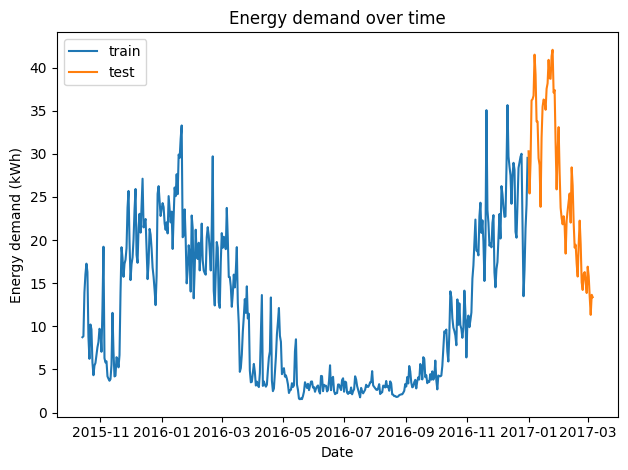

In [ ]:
plt.plot(train.index, train["energy_demand"])
plt.plot(test.index, test["energy_demand"])
plt.legend(["train", "test"])
plt.xlabel("Date")
plt.ylabel("Energy demand (kWh)")
plt.title("Energy demand over time")
plt.tight_layout()
plt.show()


In [ ]:
# LSTM helper functions
def encode_features(train_df, test_df):
    cat_cols = ['is_holiday_or_weekend', 'season']

    train_num = train_df.drop(columns=cat_cols)
    test_num = test_df.drop(columns=cat_cols)

    train_cat = train_df[cat_cols]
    test_cat = test_df[cat_cols]

    encoder = OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )

    train_cat_encoded = encoder.fit_transform(train_cat)
    test_cat_encoded = encoder.transform(test_cat)

    encoded_cols = encoder.get_feature_names_out(cat_cols)

    train_cat_df = pd.DataFrame(train_cat_encoded, columns=encoded_cols, index=train_df.index)
    test_cat_df = pd.DataFrame(test_cat_encoded, columns=encoded_cols, index=test_df.index)

    train_final = pd.concat([train_num, train_cat_df], axis=1)
    test_final = pd.concat([test_num, test_cat_df], axis=1)

    return train_final, test_final


def scale_data_new(train, val, test):
    scaler = MinMaxScaler()

    columns = train.columns

    train[columns] = scaler.fit_transform(train[columns])
    val[columns] = scaler.transform(val[columns])
    test[columns] = scaler.transform(test[columns])

    return train, val, test, scaler


def split_train(train_df, val_size=30):
    train_df = train_df.sort_index()
    val_df = train_df.iloc[-val_size:].copy()
    train_df = train_df.iloc[:-val_size].copy()

    return train_df, val_df

def create_sequences(train, val, test, k, f=1):
    """ k - number of past time steps to use for prediction;
        f - number of future time steps to predict
    """

    FUTURE_FEATURES = ['is_holiday_or_weekend_True', 'season_spring', 'season_summer', 'season_winter']  # known at prediction time

    ALL_FEATURES = [
        'energy_demand', 'dishwasher', 'ev', 'freezer', 'grid_export',
        'heat_pump', 'pv', 'washing_machine', 'temperature',
        'radiation_direct_horizontal', 'radiation_diffuse_horizontal',
    ] + FUTURE_FEATURES

    TARGET = 'energy_demand'

    combined = pd.concat([train, val, test]).sort_index()

    X_past, y = [], []

    for i in range(len(combined) - k - f + 1):
        past = combined.iloc[i:i+k][ALL_FEATURES].values
        target = combined.iloc[i+k:i+k+f][TARGET].values

        X_past.append(past)
        y.append(target)


    train_end = len(train) - k
    val_end = train_end + len(val)

    X_past_train = X_past[:train_end]
    y_train = y[:train_end]

    X_past_val = X_past[train_end:val_end]
    y_val = y[train_end:val_end]

    X_past_test = X_past[val_end:]
    y_test = y[val_end:]

    return (
        np.array(X_past_train), np.array(y_train),
        np.array(X_past_val), np.array(y_val),
        np.array(X_past_test), np.array(y_test)
    )

### One-step ahead Forecasting
#### ARIMA model

In [ ]:
# arima fit
history = train["energy_demand"].copy().tolist()
arima_preds = []
fitted_values = []
for i in range(len(test)):
    decomp = seasonal_decompose(history, model="additive", period=7, extrapolate_trend="freq")
    deseasonalized = history - decomp.seasonal
    seasonal_cycle = decomp.seasonal[:7]
    arima = ARIMA(deseasonalized, order=(1,1,2)).fit()
    y_hat = arima.forecast()[0] + seasonal_cycle[len(history) % 7]
    arima_preds.append(y_hat)
    history.append(test["energy_demand"].iloc[i])
    if i == 0:
        fitted_values = arima.fittedvalues + decomp.seasonal[:len(arima.fittedvalues)]

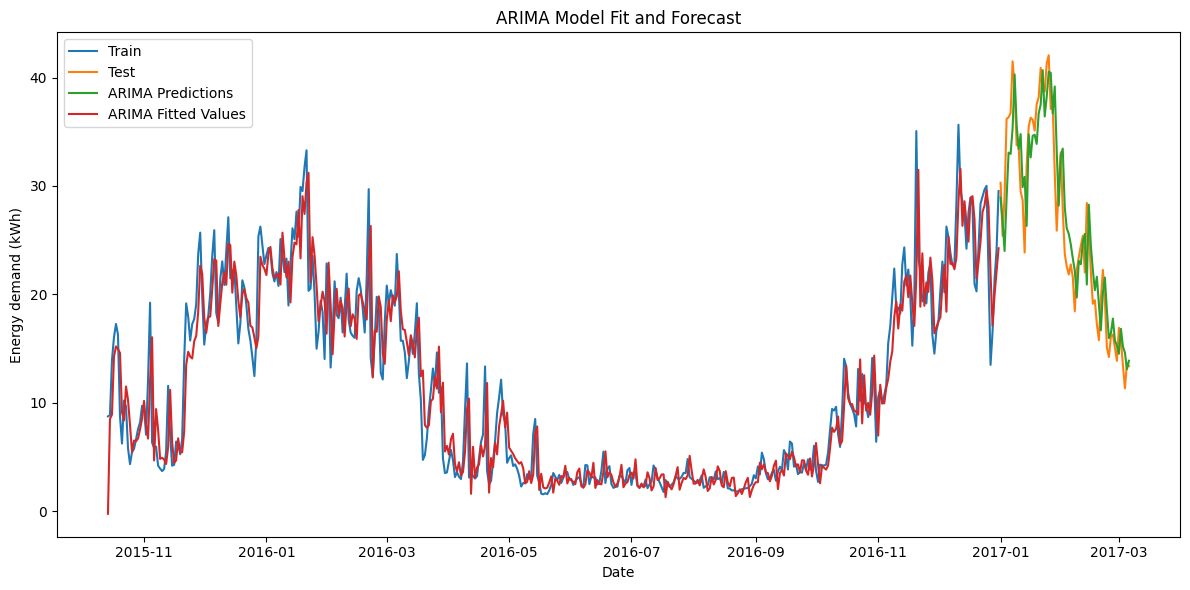

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train["energy_demand"], label="Train")
plt.plot(test.index, test["energy_demand"], label="Test")
plt.plot(test.index, arima_preds, label="ARIMA Predictions")
plt.plot(train.index[:len(fitted_values)], fitted_values, label="ARIMA Fitted Values")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Energy demand (kWh)")
plt.title("ARIMA Model Fit and Forecast")
plt.tight_layout()
plt.show()

#### Prophet model

In [ ]:
# prophet fit
cat_cols = ['is_holiday_or_weekend', 'season']

train_target = train[["energy_demand"]]
test_target = test[["energy_demand"]]

train_cat = train[cat_cols]
test_cat = test[cat_cols]

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

train_cat_encoded = encoder.fit_transform(train_cat)
test_cat_encoded = encoder.transform(test_cat)

encoded_cols = encoder.get_feature_names_out(cat_cols)

train_cat_df = pd.DataFrame(train_cat_encoded, columns=encoded_cols, index=train.index)
test_cat_df = pd.DataFrame(test_cat_encoded, columns=encoded_cols, index=test.index)

train_final = pd.concat([train_target, train_cat_df], axis=1)
test_final = pd.concat([test_target, test_cat_df], axis=1)

train_final = train_final.reset_index().rename(columns={'utc_timestamp': 'ds', 'energy_demand': 'y'})
train_final['ds'] = train_final['ds'].dt.tz_localize(None)
test_final = test_final.reset_index().rename(columns={'utc_timestamp': 'ds', 'energy_demand': 'y'})
test_final['ds'] = test_final['ds'].dt.tz_localize(None)

regressor_cols = train_final.columns.difference(['ds', 'y'])
_train_df = train_final.copy()
rows = []
prophet_preds = []

for i in range(len(test_final)):

    m = prophet.Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)

    for col in regressor_cols:
        m.add_regressor(col)

    m.fit(_train_df)

    _train_df = pd.concat([_train_df, test_final.iloc[i:i+1]], ignore_index=True)
    future = _train_df.drop(columns=['y'])

    forecast = m.predict(future)
    next_row = forecast.iloc[-1]
    rows.append(next_row)
    prophet_preds.append(next_row['yhat'])

21:21:53 - cmdstanpy - INFO - Chain [1] start processing
21:21:53 - cmdstanpy - INFO - Chain [1] done processing
21:21:53 - cmdstanpy - INFO - Chain [1] start processing
21:21:53 - cmdstanpy - INFO - Chain [1] done processing
21:21:53 - cmdstanpy - INFO - Chain [1] start processing
21:21:53 - cmdstanpy - INFO - Chain [1] done processing
21:21:53 - cmdstanpy - INFO - Chain [1] start processing
21:21:53 - cmdstanpy - INFO - Chain [1] done processing
21:21:53 - cmdstanpy - INFO - Chain [1] start processing
21:21:53 - cmdstanpy - INFO - Chain [1] done processing
21:21:54 - cmdstanpy - INFO - Chain [1] start processing
21:21:54 - cmdstanpy - INFO - Chain [1] done processing
21:21:54 - cmdstanpy - INFO - Chain [1] start processing
21:21:54 - cmdstanpy - INFO - Chain [1] done processing
21:21:54 - cmdstanpy - INFO - Chain [1] start processing
21:21:54 - cmdstanpy - INFO - Chain [1] done processing
21:21:54 - cmdstanpy - INFO - Chain [1] start processing
21:21:54 - cmdstanpy - INFO - Chain [1]

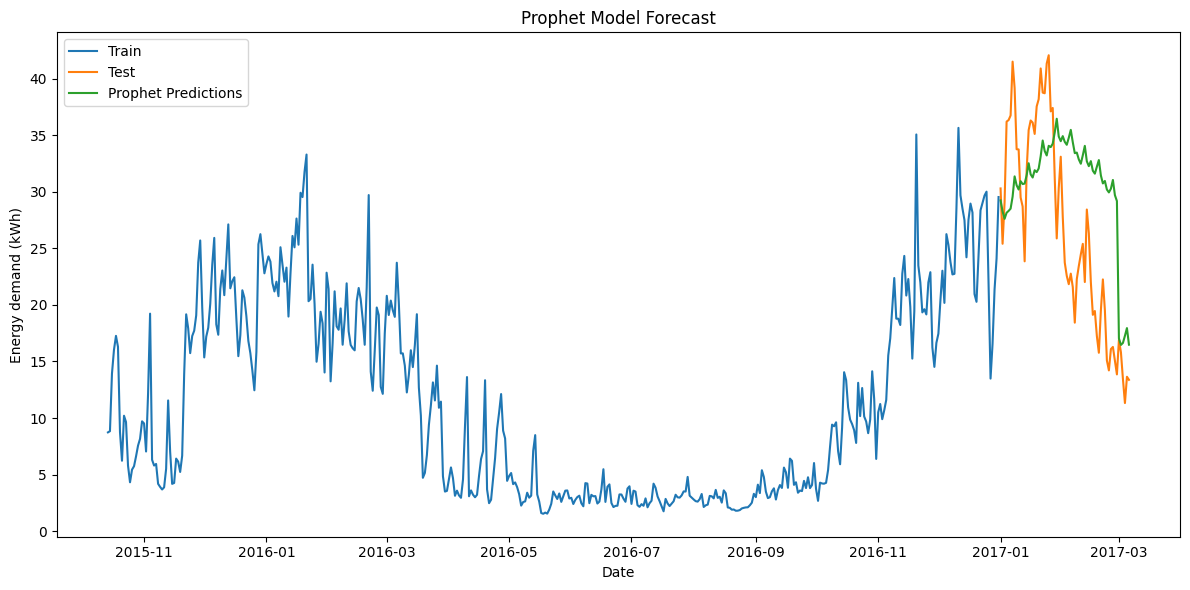

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train["energy_demand"], label="Train")
plt.plot(test.index, test["energy_demand"], label="Test")
plt.plot(test.index, prophet_preds, label="Prophet Predictions")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Energy demand (kWh)")
plt.title("Prophet Model Forecast")
plt.tight_layout()
plt.show()

#### LSTM model

In [ ]:
train_df, test_df = encode_features(train, test)  # categorical encoding

val_size = 111
train_df, val_df = split_train(train_df, val_size=val_size)  # train-val split

train_df, val_df, test_df, scaler = scale_data_new(train_df, val_df, test_df)  # scaling

In [ ]:
lag_grid = [
    [1],
    [1, 2],
    [1, 2, 3],
    [1, 2, 3, 4]
]
hidden_units_grid = [25, 50, 100]

models = {}
histories = {}


for lags in lag_grid:  # hyperameter grid search
    for hidden_units in hidden_units_grid:
        print(f"Training univariate LSTM with lags={lags} and hidden_units={hidden_units}...")

        X_past_train, y_train, X_past_val, y_val, X_past_test, y_test = create_sequences(train_df, val_df, test_df, k=lags[-1], f=1)

        univariate_lstm = Sequential()
        univariate_lstm.add(LSTM(hidden_units, activation="relu", input_shape=(30, 1)))
        univariate_lstm.add(Dense(1))
        univariate_lstm.compile(optimizer="adam", loss="mse")
        early_stopping = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

        history = univariate_lstm.fit(
            X_past_train[:, -1:, 0], y_train,
            validation_data=(X_past_val[:, -1:, 0], y_val),
            epochs=100,
            batch_size=8,
            callbacks=[early_stopping],
            verbose=0
        )

        print(f"Validation loss: {min(history.history['val_loss']):.4f}")

        models[(tuple(lags), hidden_units)] = univariate_lstm
        histories[(tuple(lags), hidden_units)] = history



Training univariate LSTM with lags=[1] and hidden_units=25...


/Users/tomasz/PycharmProjects/ML_labs/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1778182090.616012 15033617 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2

Validation loss: 0.0128
Training univariate LSTM with lags=[1] and hidden_units=50...
Validation loss: 0.0128
Training univariate LSTM with lags=[1] and hidden_units=100...


E0000 00:00:1778182096.463186 15033617 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Validation loss: 0.0106
Training univariate LSTM with lags=[1, 2] and hidden_units=25...


...

Validation loss: 0.0113
Training univariate LSTM with lags=[1, 2, 3, 4] and hidden_units=50...


E0000 00:00:1778182144.609147 15033617 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Validation loss: 0.0115
Training univariate LSTM with lags=[1, 2, 3, 4] and hidden_units=100...


E0000 00:00:1778182150.776236 15033617 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Validation loss: 0.0116


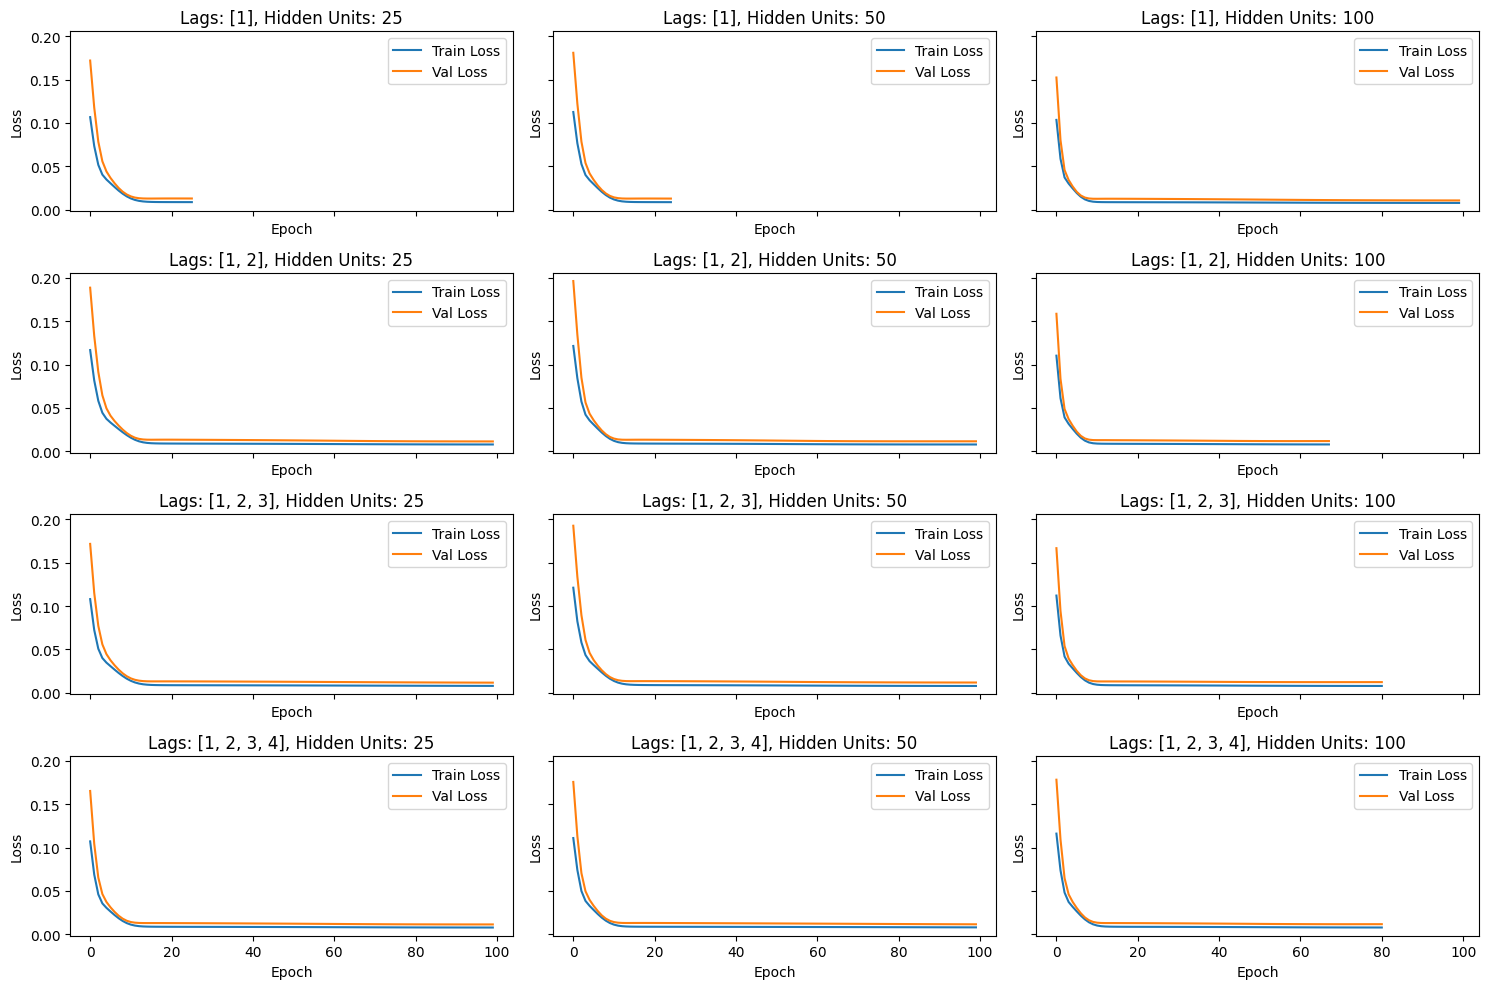

In [ ]:
fig, ax = plt.subplots(len(lag_grid), len(hidden_units_grid), figsize=(15, 10), sharex=True, sharey=True)

for i, lags in enumerate(lag_grid):
    for j, hidden_units in enumerate(hidden_units_grid):
        history = histories[(tuple(lags), hidden_units)]
        ax[i, j].plot(history.history["loss"], label="Train Loss")
        ax[i, j].plot(history.history["val_loss"], label="Val Loss")
        ax[i, j].set_title(f"Lags: {lags}, Hidden Units: {hidden_units}")
        ax[i, j].legend()
        ax[i, j].set_xlabel("Epoch")
        ax[i, j].set_ylabel("Loss")
plt.tight_layout()
plt.show()

In [ ]:
best_model_key = min(histories, key=lambda k: min(histories[k].history["val_loss"]))
best_model = models[best_model_key]
print(f"Best model - Lags: {best_model_key[0]}, Hidden Units: {best_model_key[1]}")

Best model - Lags: (1,), Hidden Units: 100


 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

E0000 00:00:1778182243.838716 15033617 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


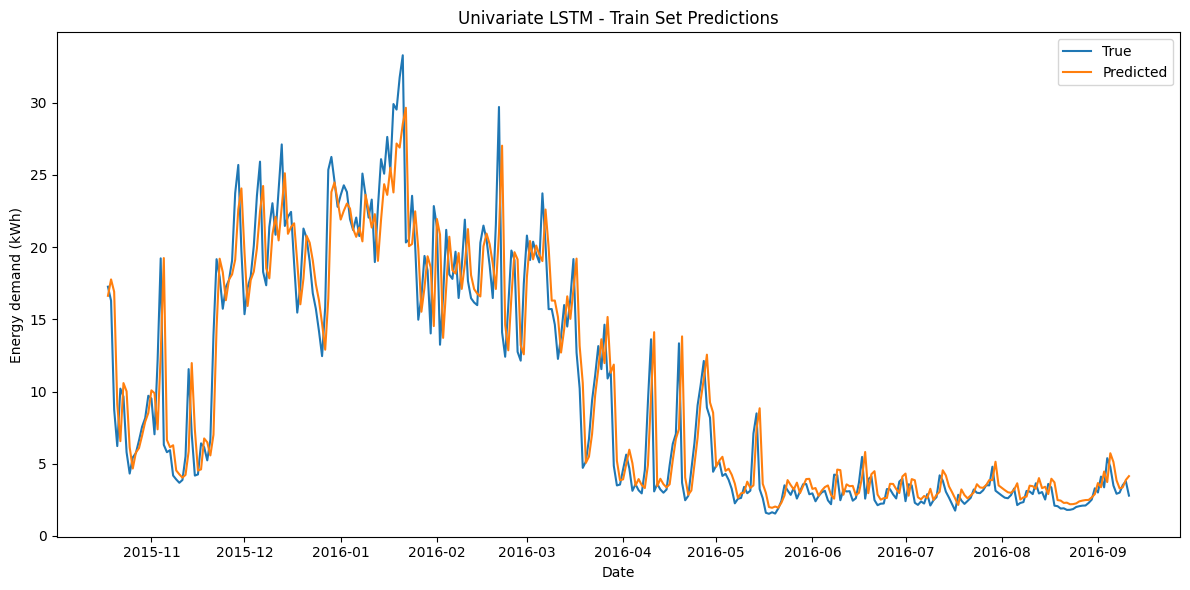

In [ ]:
# train predictions
y_train_pred = best_model.predict(X_past_train[:, -1:, 0])
y_train_pred_rescaled = scaler.inverse_transform(
    np.hstack([y_train_pred, np.zeros((y_train_pred.shape[0], len(train_df.columns)-1))])
)[:, 0]

plt.figure(figsize=(12, 6))
plt.plot(train.index[lags[-1]:lags[-1]+len(y_train)], scaler.inverse_transform(
    np.hstack([y_train, np.zeros((y_train.shape[0], len(train_df.columns)-1))])
)[:, 0], label="True")
plt.plot(train.index[lags[-1]:lags[-1]+len(y_train)], y_train_pred_rescaled, label="Predicted")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Energy demand (kWh)")
plt.title("Univariate LSTM - Train Set Predictions")
plt.tight_layout()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


E0000 00:00:1778182251.922077 15033617 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


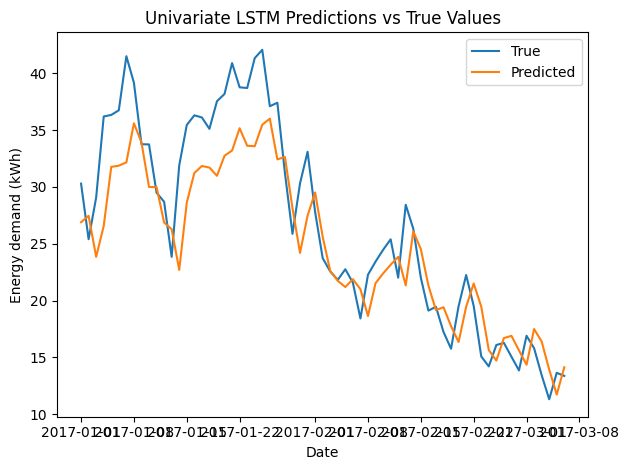

In [ ]:
preds = best_model.predict(X_past_test[:, -1:, 0])
preds_rescaled = scaler.inverse_transform(
    np.concatenate([
        preds,
        X_past_test[:, -1:, 1:].reshape(-1, len(train_df.columns)-1)
    ], axis=1)
)[:, 0]

plt.figure(figsize=(12, 6))
plt.plot(test.index[-len(preds_rescaled):], test["energy_demand"][-len(preds_rescaled):], label="True")
plt.plot(test.index[-len(preds_rescaled):], preds_rescaled, label="Predicted")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Energy demand (kWh)")
plt.title("Univariate LSTM Predictions vs True Values")
plt.tight_layout()
plt.show()

#### One-step ahead models comparison

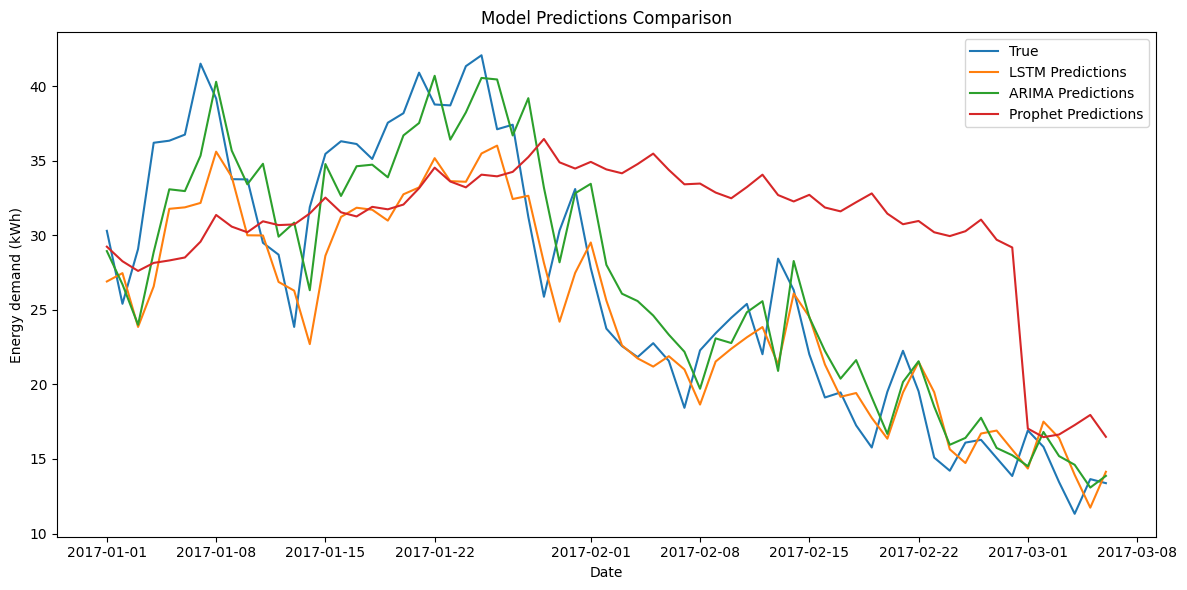

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(test.index, test["energy_demand"], label="True")
plt.plot(test.index, preds_rescaled, label="LSTM Predictions")
plt.plot(test.index, arima_preds, label="ARIMA Predictions")
plt.plot(test.index, prophet_preds, label="Prophet Predictions")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Energy demand (kWh)")
plt.title("Model Predictions Comparison")
plt.tight_layout()
plt.show()

In [ ]:
mses = {
    "LSTM": np.mean((preds_rescaled - test["energy_demand"].values)**2),
    "ARIMA": np.mean((np.array(arima_preds) - test["energy_demand"].values)**2),
    "Prophet": np.mean((np.array(prophet_preds) - test["energy_demand"].values)**2)
}

maes = {
    "LSTM": np.mean(np.abs(preds_rescaled - test["energy_demand"].values)),
    "ARIMA": np.mean(np.abs(np.array(arima_preds) - test["energy_demand"].values)),
    "Prophet": np.mean(np.abs(np.array(prophet_preds) - test["energy_demand"].values))
}

mapes = {
    "LSTM": np.mean(np.abs((preds_rescaled - test["energy_demand"].values) / test["energy_demand"].values)) * 100,
    "ARIMA": np.mean(np.abs((np.array(arima_preds) - test["energy_demand"].values) / test["energy_demand"].values)) * 100,
    "Prophet": np.mean(np.abs((np.array(prophet_preds) - test["energy_demand"].values) / test["energy_demand"].values)) * 100
}

pd.DataFrame({
    "MSE": mses,
    "MAE": maes,
    "MAPE": mapes
}).T

,LSTM,ARIMA,Prophet
MSE,16.349685,11.421788,81.281096
MAE,3.265700,2.746433,7.732307
MAPE,11.936786,11.040273,35.865110


ARIMA outperformed Prophet and LSTM in terms of all the metrics. One of the reasons is strong seasonality in the data, which was handled by seasonl decomposition in ARIMA. Prophet also handles seasonality, but it is more sensitive to hyperparameters and the data size can be too short for it to perform well. LSTM, on the other hand, is a powerful model but it requires a lot of data and careful tuning to outperform classical methods, especially on univariate time series with strong seasonality.

### Multi-step Forecasting

In [ ]:
T = 7  # 7 day ahead

#### ARIMA model

In [ ]:
# arima fit
history = train["energy_demand"].copy().tolist()
arima_preds = []
for i in range(0, len(test), T):
    decomp = seasonal_decompose(history, model="additive", period=7, extrapolate_trend="freq")
    deseasonalized = history - decomp.seasonal
    seasonal_cycle = decomp.seasonal[:7]
    arima = ARIMA(deseasonalized, order=(1,1,2)).fit()
    y_hat = arima.forecast(steps=T) + seasonal_cycle[(len(history) + np.arange(T)) % 7]
    arima_preds.extend(y_hat)
    history.extend(test["energy_demand"].iloc[i:i+T])
    if i == 0:
        fitted_values = arima.fittedvalues + decomp.seasonal[:len(arima.fittedvalues)]
arima_preds = arima_preds[:len(test)]

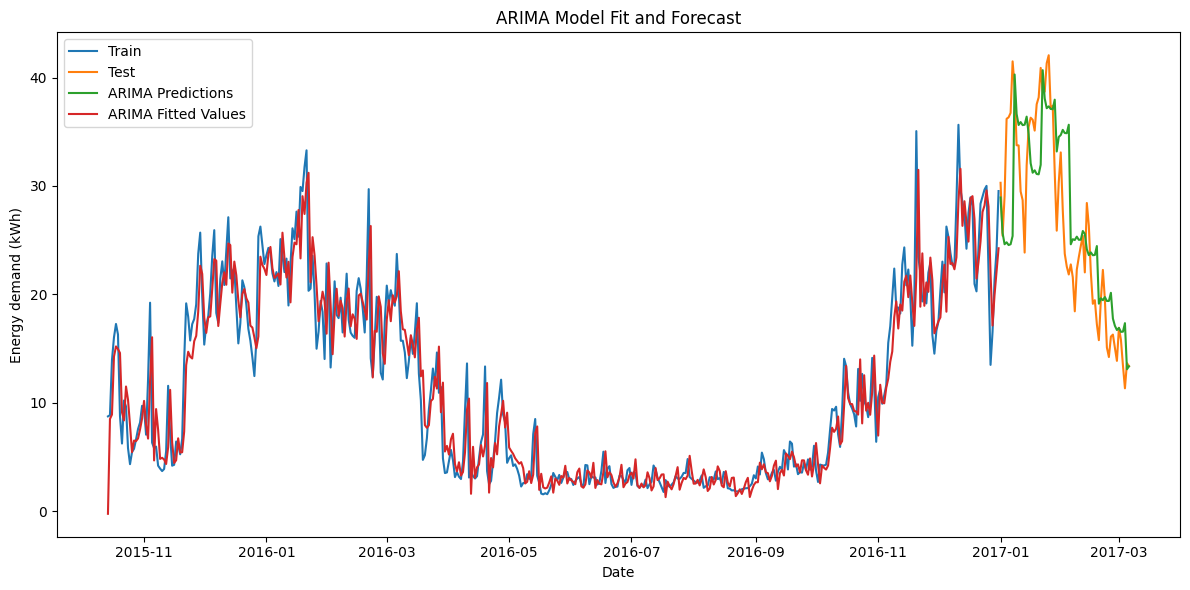

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train["energy_demand"], label="Train")
plt.plot(test.index, test["energy_demand"], label="Test")
plt.plot(test.index, arima_preds, label="ARIMA Predictions")
plt.plot(train.index[:len(fitted_values)], fitted_values, label="ARIMA Fitted Values")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Energy demand (kWh)")
plt.title("ARIMA Model Fit and Forecast")
plt.tight_layout()
plt.show()

#### Prophet model

In [ ]:
# prophet fit
cat_cols = ['is_holiday_or_weekend', 'season']

train_target = train[["energy_demand"]]
test_target = test[["energy_demand"]]

train_cat = train[cat_cols]
test_cat = test[cat_cols]

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

train_cat_encoded = encoder.fit_transform(train_cat)
test_cat_encoded = encoder.transform(test_cat)

encoded_cols = encoder.get_feature_names_out(cat_cols)

train_cat_df = pd.DataFrame(train_cat_encoded, columns=encoded_cols, index=train.index)
test_cat_df = pd.DataFrame(test_cat_encoded, columns=encoded_cols, index=test.index)

train_final = pd.concat([train_target, train_cat_df], axis=1)
test_final = pd.concat([test_target, test_cat_df], axis=1)

train_final = train_final.reset_index().rename(columns={'utc_timestamp': 'ds', 'energy_demand': 'y'})
train_final['ds'] = train_final['ds'].dt.tz_localize(None)
test_final = test_final.reset_index().rename(columns={'utc_timestamp': 'ds', 'energy_demand': 'y'})
test_final['ds'] = test_final['ds'].dt.tz_localize(None)

regressor_cols = train_final.columns.difference(['ds', 'y'])
_train_df = train_final.copy()
rows = []
prophet_preds = []
for i in range(0, len(test_final), T):

    m = prophet.Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)

    for col in regressor_cols:
        m.add_regressor(col)

    m.fit(_train_df)

    _train_df = pd.concat([_train_df, test_final.iloc[i:i+T]], ignore_index=True)
    future = _train_df.drop(columns=['y'])

    forecast = m.predict(future)
    next_rows = forecast.iloc[-T:]
    rows.append(next_rows)
    prophet_preds.extend(next_rows['yhat'])
prophet_preds = prophet_preds[:len(test)]

21:41:35 - cmdstanpy - INFO - Chain [1] start processing
21:41:35 - cmdstanpy - INFO - Chain [1] done processing
21:41:35 - cmdstanpy - INFO - Chain [1] start processing
21:41:35 - cmdstanpy - INFO - Chain [1] done processing
21:41:35 - cmdstanpy - INFO - Chain [1] start processing
21:41:36 - cmdstanpy - INFO - Chain [1] done processing
21:41:36 - cmdstanpy - INFO - Chain [1] start processing
21:41:36 - cmdstanpy - INFO - Chain [1] done processing
21:41:36 - cmdstanpy - INFO - Chain [1] start processing
21:41:36 - cmdstanpy - INFO - Chain [1] done processing
21:41:36 - cmdstanpy - INFO - Chain [1] start processing
21:41:36 - cmdstanpy - INFO - Chain [1] done processing
21:41:36 - cmdstanpy - INFO - Chain [1] start processing
21:41:36 - cmdstanpy - INFO - Chain [1] done processing
21:41:36 - cmdstanpy - INFO - Chain [1] start processing
21:41:36 - cmdstanpy - INFO - Chain [1] done processing
21:41:36 - cmdstanpy - INFO - Chain [1] start processing
21:41:36 - cmdstanpy - INFO - Chain [1]

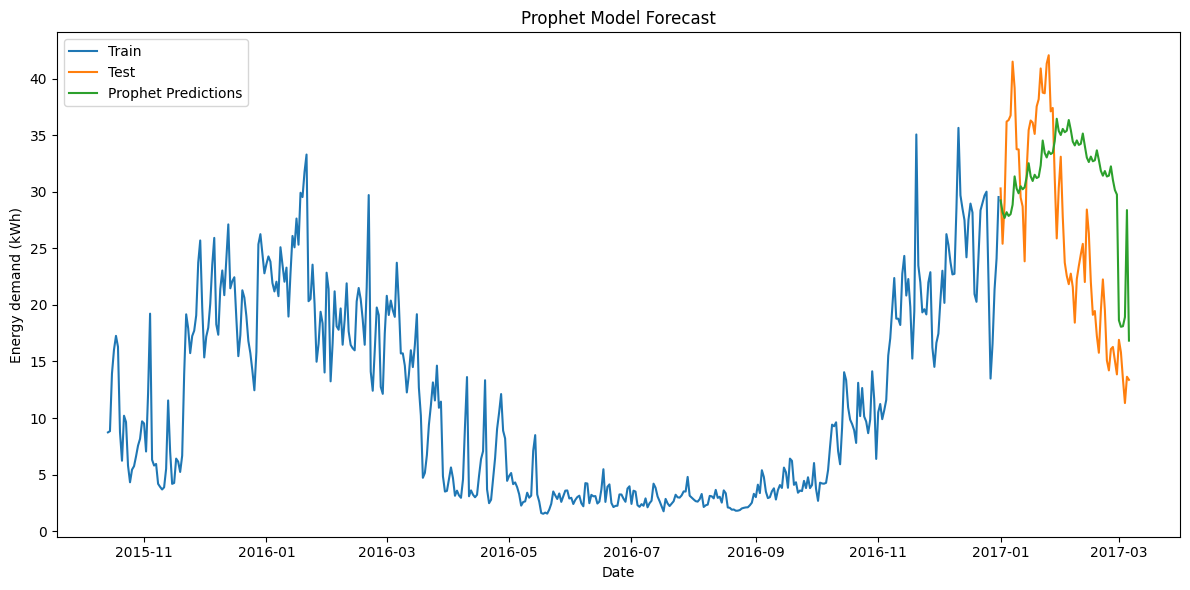

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train["energy_demand"], label="Train")
plt.plot(test.index, test["energy_demand"], label="Test")
plt.plot(test.index, prophet_preds, label="Prophet Predictions")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Energy demand (kWh)")
plt.title("Prophet Model Forecast")
plt.tight_layout()
plt.show()

#### LSTM model

In [ ]:
train_df, test_df = encode_features(train, test)

val_size = 111
train_df, val_df = split_train(train_df, val_size=val_size)

train_df, val_df, test_df, scaler = scale_data_new(train_df, val_df, test_df)

In [ ]:
lag_grid = [
    [1],
    [1, 2],
    [1, 2, 3],
    [1, 2, 3, 4]
]
hidden_units_grid = [25, 50, 100]

models = {}
histories = {}

for lags in lag_grid:
    for hidden_units in hidden_units_grid:
        print(f"Training univariate LSTM with lags={lags} and hidden_units={hidden_units}...")

        X_past_train, y_train, X_past_val, y_val, X_past_test, y_test = create_sequences(train_df, val_df, test_df, k=lags[-1], f=T)

        multivariate_lstm = Sequential()
        multivariate_lstm.add(LSTM(hidden_units, activation="relu", input_shape=(30, train_df.shape[1])))
        multivariate_lstm.add(Dense(T))
        multivariate_lstm.compile(optimizer="adam", loss="mse")
        early_stopping = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

        history = multivariate_lstm.fit(
            X_past_train, y_train,
            validation_data=(X_past_val, y_val),
            epochs=100,
            batch_size=8,
            callbacks=[early_stopping],
            verbose=0
        )

        print(f"Validation loss: {min(history.history['val_loss']):.4f}")

        models[(tuple(lags), hidden_units)] = multivariate_lstm
        histories[(tuple(lags), hidden_units)] = history

Training univariate LSTM with lags=[1] and hidden_units=25...


/Users/tomasz/PycharmProjects/ML_labs/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1778183087.052061 15033617 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2

Validation loss: 0.0237
Training univariate LSTM with lags=[1] and hidden_units=50...


E0000 00:00:1778183092.397980 15033617 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Validation loss: 0.0230
Training univariate LSTM with lags=[1] and hidden_units=100...


...

Validation loss: 0.0252
Training univariate LSTM with lags=[1, 2, 3] and hidden_units=100...


E0000 00:00:1778183120.739934 15033617 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Validation loss: 0.0308
Training univariate LSTM with lags=[1, 2, 3, 4] and hidden_units=25...
Validation loss: 0.0203
Training univariate LSTM with lags=[1, 2, 3, 4] and hidden_units=50...


E0000 00:00:1778183127.086342 15033617 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Validation loss: 0.0251
Training univariate LSTM with lags=[1, 2, 3, 4] and hidden_units=100...
Validation loss: 0.0280


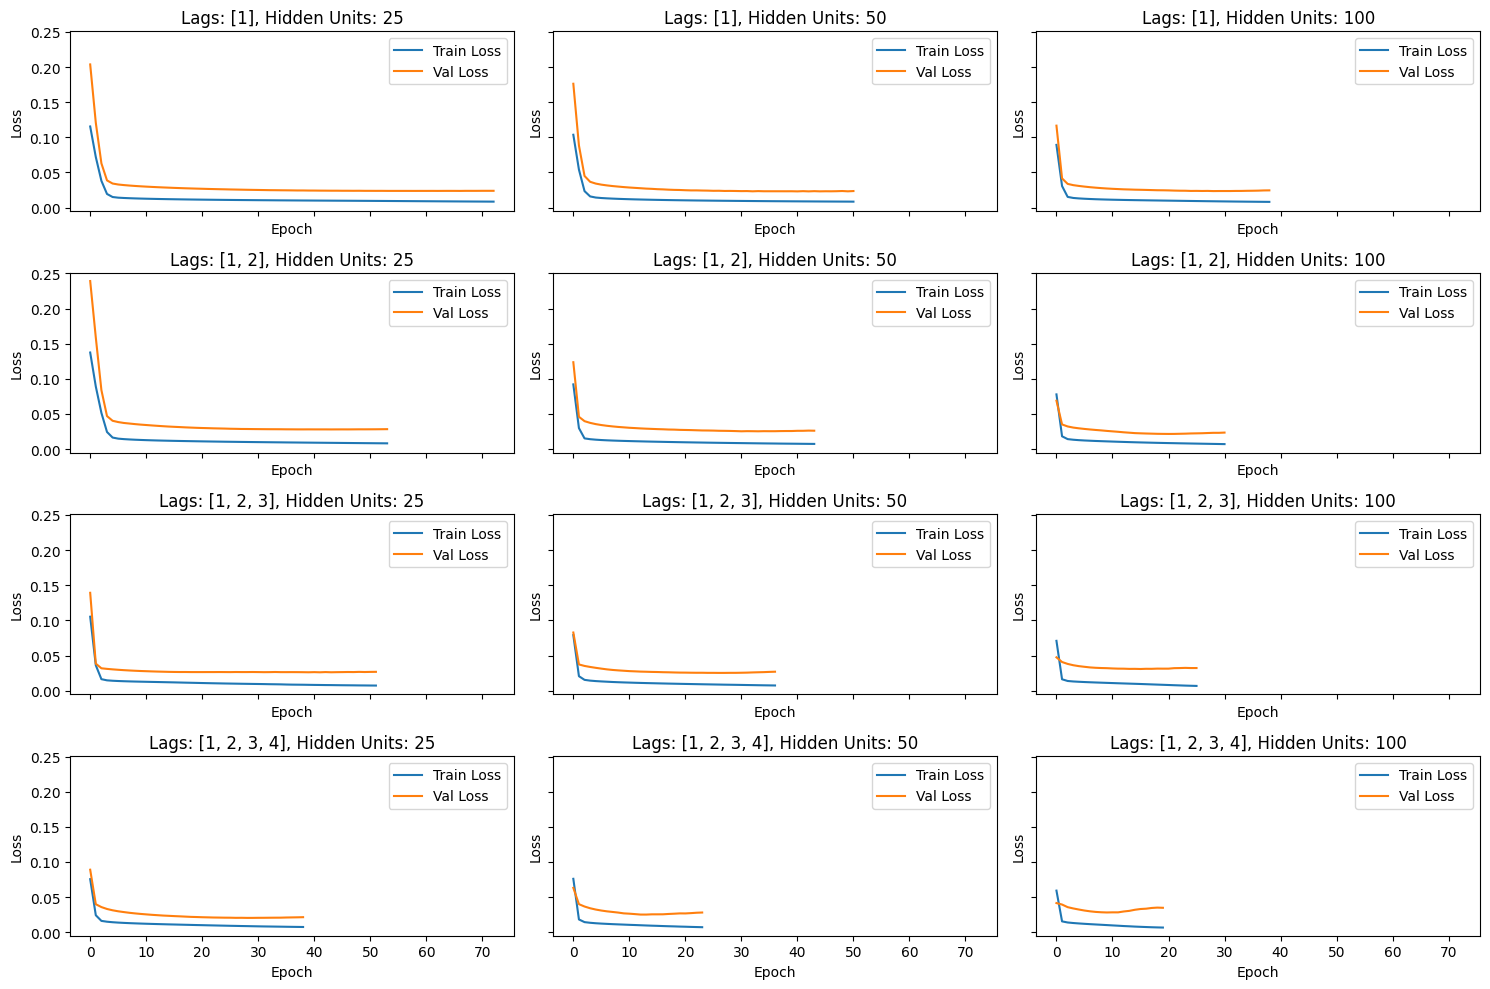

In [ ]:
fig, ax = plt.subplots(len(lag_grid), len(hidden_units_grid), figsize=(15, 10), sharex=True, sharey=True)
for i, lags in enumerate(lag_grid):
    for j, hidden_units in enumerate(hidden_units_grid):
        history = histories[(tuple(lags), hidden_units)]
        ax[i, j].plot(history.history["loss"], label="Train Loss")
        ax[i, j].plot(history.history["val_loss"], label="Val Loss")
        ax[i, j].set_title(f"Lags: {lags}, Hidden Units: {hidden_units}")
        ax[i, j].legend()
        ax[i, j].set_xlabel("Epoch")
        ax[i, j].set_ylabel("Loss")
plt.tight_layout()
plt.show()

LSTM convergence is quite poor, the reason can be even shorter of a dataset due to longer prediction horizons and more complex model. Hyperparameter tuning is also more difficult in this case, which can lead to suboptimal performance.

In [ ]:
best_model_key = min(histories, key=lambda k: min(histories[k].history["val_loss"]))
best_model = models[best_model_key]
X_past_test, y_test = create_sequences(train_df, val_df, test_df, k=best_model_key[0][-1], f=T)[4:6]
print(f"Best model - Lags: {best_model_key[0]}, Hidden Units: {best_model_key[1]}")

Best model - Lags: (1, 2, 3, 4), Hidden Units: 25


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


E0000 00:00:1778268448.584402 15033617 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


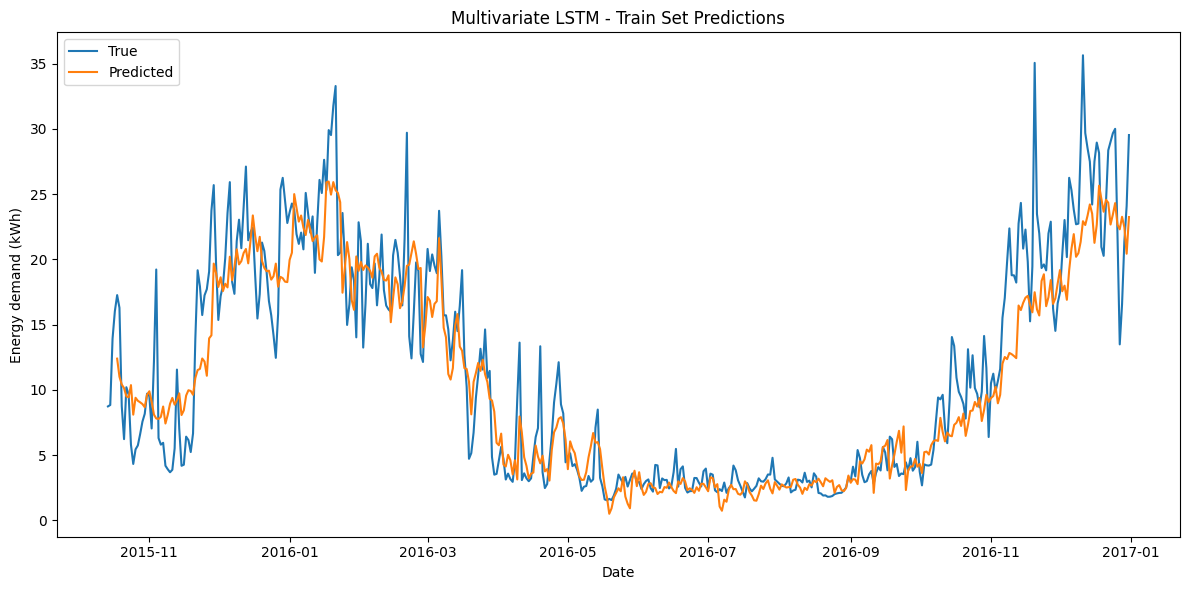

In [ ]:
# train predictions
y_train_pred = best_model.predict(X_past_train)
y_val_pred = best_model.predict(X_past_val)

cnct = np.r_[y_train_pred.flatten(), y_val_pred.flatten()]
y_train_val_pred_scaled = scaler.inverse_transform(np.hstack([cnct.reshape(-1, 1), np.zeros((cnct.size, train_df.shape[1]-1))]))[:, 0]
pred_seqs = np.array([y_train_val_pred_scaled[i: i+T] for i in range(0, len(y_train_val_pred_scaled), T)])

indx_pred_pairs = [[pd.concat([train, test]).index[i:i+T], pred_seqs[i - best_model_key[0][-1]]] for i in range(best_model_key[0][-1], len(train), T)]
indices = [pair[0] for pair in indx_pred_pairs]
indices = pd.Index(np.array(indices).flatten())
preds = [pair[1] for pair in indx_pred_pairs]
preds = np.array(preds).flatten()

plt.figure(figsize=(12, 6))
plt.plot(train.index, train["energy_demand"], label="True")
plt.plot(indices, preds, label="Predicted")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Energy demand (kWh)")
plt.title("Multivariate LSTM - Train Set Predictions")
plt.tight_layout()
plt.show()


#### Multi-step models comparison

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


E0000 00:00:1778269871.542651 15033617 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


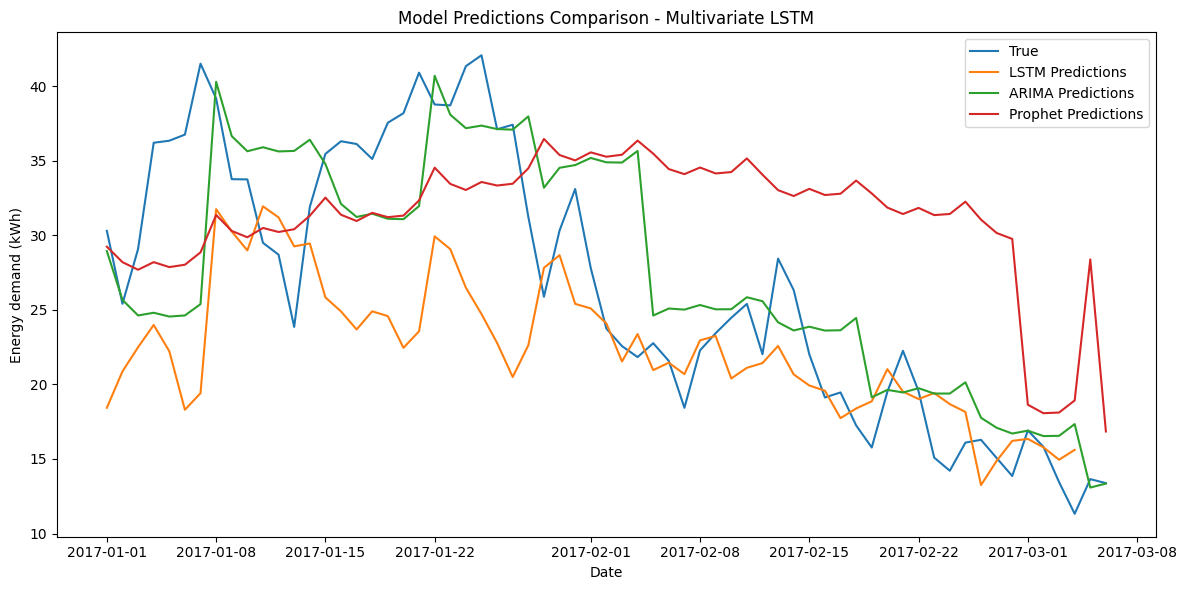

In [ ]:
# test predictions
preds = best_model.predict(X_past_test).flatten()
preds_rescaled = scaler.inverse_transform(np.hstack([preds.reshape(-1, 1), np.zeros((preds.size, train_df.shape[1]-1))]))[:, 0]
pred_seqs = np.array([preds_rescaled[i: i+T] for i in range(0, len(preds_rescaled), T)])

indx_pred_pairs = [[test.index[i:min(i+T, len(test))], pred_seqs[i]] for i in range(0, len(test)-T, T)]
indices = [pair[0] for pair in indx_pred_pairs]
indices = pd.Index(np.array(indices).flatten())
preds = [pair[1] for pair in indx_pred_pairs]
preds = np.array(preds).flatten()

plt.figure(figsize=(12, 6))
plt.plot(test.index, test["energy_demand"], label="True")
plt.plot(indices, preds, label="LSTM Predictions")
plt.plot(test.index, arima_preds, label="ARIMA Predictions")
plt.plot(test.index, prophet_preds, label="Prophet Predictions")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Energy demand (kWh)")
plt.title("Model Predictions Comparison - Multivariate LSTM")
plt.tight_layout()
plt.show()

In [ ]:
mses = {
    "Multivariate LSTM": np.mean((preds - test.loc[indices]["energy_demand"])**2),
    "ARIMA": np.mean((np.array(arima_preds) - test["energy_demand"].values)**2),
    "Prophet": np.mean((np.array(prophet_preds) - test["energy_demand"].values)**2)
}

maes = {
    "Multivariate LSTM": np.mean(np.abs(preds - test.loc[indices]["energy_demand"])),
    "ARIMA": np.mean(np.abs(np.array(arima_preds) - test["energy_demand"].values)),
    "Prophet": np.mean(np.abs(np.array(prophet_preds) - test["energy_demand"].values))
}

mapes = {
    "Multivariate LSTM": np.mean(np.abs((preds - test.loc[indices]["energy_demand"]) / test.loc[indices]["energy_demand"])) * 100,
    "ARIMA": np.mean(np.abs((np.array(arima_preds) - test["energy_demand"].values) / test["energy_demand"].values)) * 100,
    "Prophet": np.mean(np.abs((np.array(prophet_preds) - test["energy_demand"].values) / test["energy_demand"].values)) * 100
}

pd.DataFrame({
    "MSE": mses,
    "MAE": maes,
    "MAPE": mapes
}).T

,Multivariate LSTM,ARIMA,Prophet
MSE,67.749522,34.075608,95.207168
MAE,5.984721,4.429312,8.453040
MAPE,19.313459,17.568305,39.835995


The trend from one-step ahead forecasting continues in the multivariate case, with ARIMA outperforming Prophet and LSTM. The added complexity of multivariate forecasting can further challenge LSTM, especially if the dataset is not sufficiently large or if the relationships between variables are not well captured by the model. Prophet's performance can also degrade if the additional features do not provide significant predictive power or if the model is not properly tuned to handle them.

## Problem 4.2: Attention Mechanisms (25 points)
Implement attention layer for sequence modeling:

• Add attention mechanism to LSTM model from Problem 4.1.

• Visualize attention weights over input sequences.

• Analyze which time steps receive highest attention.

We implemented an attention mechanism on top of the LSTM model which performed the best in the previous problem. We focused on the one-step-ahead prediction case, as it already showed significant performance differences between models. The attention mechanism allows the model to weigh different time steps of the input sequence differently when making predictions, which can help capture important temporal dependencies.

In [ ]:
train_df, test_df = encode_features(train, test)

val_size = 111
train_df, val_df = split_train(train_df, val_size=val_size)

train_df, val_df, test_df, scaler = scale_data_new(train_df, val_df, test_df)

X_past_train, y_train, X_past_val, y_val, X_past_test, y_test = create_sequences(train_df, val_df, test_df, k=4, f=1)
X_past_train = np.concatenate([X_past_train, X_past_val], axis=0)
y_train = np.concatenate([y_train, y_val], axis=0)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import LSTM, MultiHeadAttention, LayerNormalization, Dropout, Dense


# Custom layer to retrieve attention weights from MultiHeadAttention
class MultiHeadAttentionWithWeights(layers.Layer):
    """
    MultiHeadAttention layer that stores attention weights for visualization.
    Allows retrieval of attention weights to create attention heatmaps.
    """
    def __init__(self, embed_dim, num_heads, dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        self.mha = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=dropout,
            attention_axes=None
        )
        self.attention_weights = None

    def call(self, query, key, value, attention_mask=None, training=None):
        attn_output, attn_weights = self.mha(
            query, value, key,
            attention_mask=attention_mask,
            training=training,
            return_attention_scores=True
        )
        # Store weights for later retrieval (batch, num_heads, seq_len_q, seq_len_k)
        self.attention_weights = attn_weights
        return attn_output, attn_weights


class LSTMAttentionModelKeras(Model):
    """
    Keras implementation of LSTM with MultiHeadAttention for one-step-ahead prediction.

    Architecture:
    - LSTM encoder over input sequence
    - Self-attention over all LSTM outputs (MultiHeadAttention with Q=K=V)
    - Layer normalization with residual connection
    - Global average pooling
    - Dense prediction head

    Supports attention weight retrieval for interpretability (heatmaps).
    """
    def __init__(self, input_size=2, hidden=64, num_lstm_layers=2,
                 dropout=0.2, num_heads=4, **kwargs):
        super().__init__(**kwargs)
        self.input_size = input_size
        self.hidden = hidden
        self.num_lstm_layers = num_lstm_layers
        self.dropout_rate = dropout
        self.num_heads = num_heads

        # LSTM layers (stacked)
        self.lstm_layers = [
            LSTM(hidden,
                 return_sequences=True,
                 dropout=dropout if i < num_lstm_layers - 1 else 0.0,
                 recurrent_dropout=dropout if i < num_lstm_layers - 1 else 0.0)
            for i in range(num_lstm_layers)
        ]

        # MultiHeadAttention with weights tracking
        self.mha_layer = MultiHeadAttentionWithWeights(
            embed_dim=hidden,
            num_heads=num_heads,
            dropout=dropout
        )

        # Normalization and regularization
        self.layer_norm = LayerNormalization(epsilon=1e-6)
        self.dropout = Dropout(dropout)

        # Prediction head (similar to PyTorch Sequential)
        self.dense1 = Dense(32, activation='gelu')
        self.dense2 = Dense(1)

        # Store attention weights for later access
        self.last_attention_weights = None

    def call(self, inputs, training=None):
        """
        Forward pass.

        Args:
            inputs: (batch_size, seq_len, input_size) tensor
            training: boolean or None for training mode

        Returns:
            predictions: (batch_size,) tensor of one-step-ahead predictions
        """
        # LSTM encoding
        x = inputs
        for lstm_layer in self.lstm_layers:
            x = lstm_layer(x, training=training)
        lstm_out = x  # (batch, seq_len, hidden)

        # Self-attention: Q = K = V = lstm_out
        attn_out, attn_weights = self.mha_layer(
            lstm_out, lstm_out, lstm_out,
            training=training
        )
        self.last_attention_weights = attn_weights

        # Residual connection + layer normalization
        out = lstm_out + attn_out
        out = self.layer_norm(out)

        # Global average pooling
        pooled = tf.reduce_mean(out, axis=1)  # (batch, hidden)
        pooled = self.dropout(pooled, training=training)

        # Prediction head
        head_out = self.dense1(pooled)
        predictions = self.dense2(head_out)
        predictions = tf.squeeze(predictions, axis=-1)  # (batch,)

        return predictions

    def get_attention_weights(self):
        """
        Retrieve attention weights from the last forward pass.

        Returns:
            attention_weights: (batch_size, num_heads, seq_len_q, seq_len_k) tensor
                             or None if no forward pass has been run yet.
        """
        return self.last_attention_weights

    def get_attention_heatmap(self, sample_idx=0, head_idx=None):
        """
        Extract attention weights for a specific sample and optionally head.
        Useful for visualization.

        Args:
            sample_idx: batch index to extract
            head_idx: attention head index (if None, averages over all heads)

        Returns:
            heatmap: (seq_len_q, seq_len_k) numpy array
        """
        if self.last_attention_weights is None:
            raise ValueError("No attention weights available. Run a forward pass first.")

        weights = self.last_attention_weights.numpy()  # (batch, num_heads, seq_q, seq_k)
        sample_weights = weights[sample_idx]  # (num_heads, seq_q, seq_k)

        if head_idx is not None:
            heatmap = sample_weights[head_idx]  # (seq_q, seq_k)
        else:
            # Average over all heads
            heatmap = np.mean(sample_weights, axis=0)

        return heatmap


# Create the Keras LSTM-Attention model
lstm_attn_model = LSTMAttentionModelKeras(
    input_size=X_past_train.shape[2],  # Using univariate for now
    hidden=8,
    num_lstm_layers=2,
    dropout=0.2,
    num_heads=4,
)

lstm_attn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
early_stopping_attn = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_attn = lstm_attn_model.fit(
    X_past_train,  # Keep 3D shape for LSTM
    y_train,
    validation_data=(X_past_test, y_test),
    epochs=100,
    batch_size=8,
    callbacks=[early_stopping_attn],
    verbose=0
)

print("LSTM-Attention model trained successfully!")
print(f"Best validation loss: {min(history_attn.history['val_loss']):.6f}")

E0000 00:00:1778271777.437224 15033617 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


LSTM-Attention model trained successfully!
Best validation loss: 0.087863


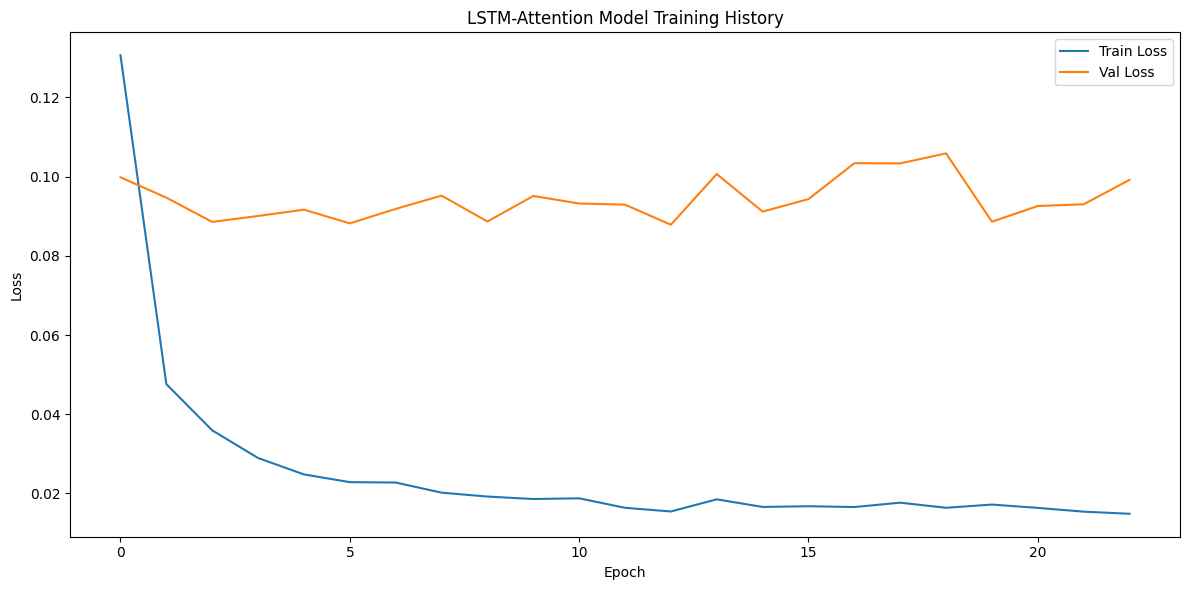

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(history_attn.history['loss'], label='Train Loss')
plt.plot(history_attn.history['val_loss'], label='Val Loss')
plt.title('LSTM-Attention Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

The model can be however too complex for the dataset since we cannot see convergence in the training process.

LSTM-Attention prediction: 0.065194
Actual value: 0.905650


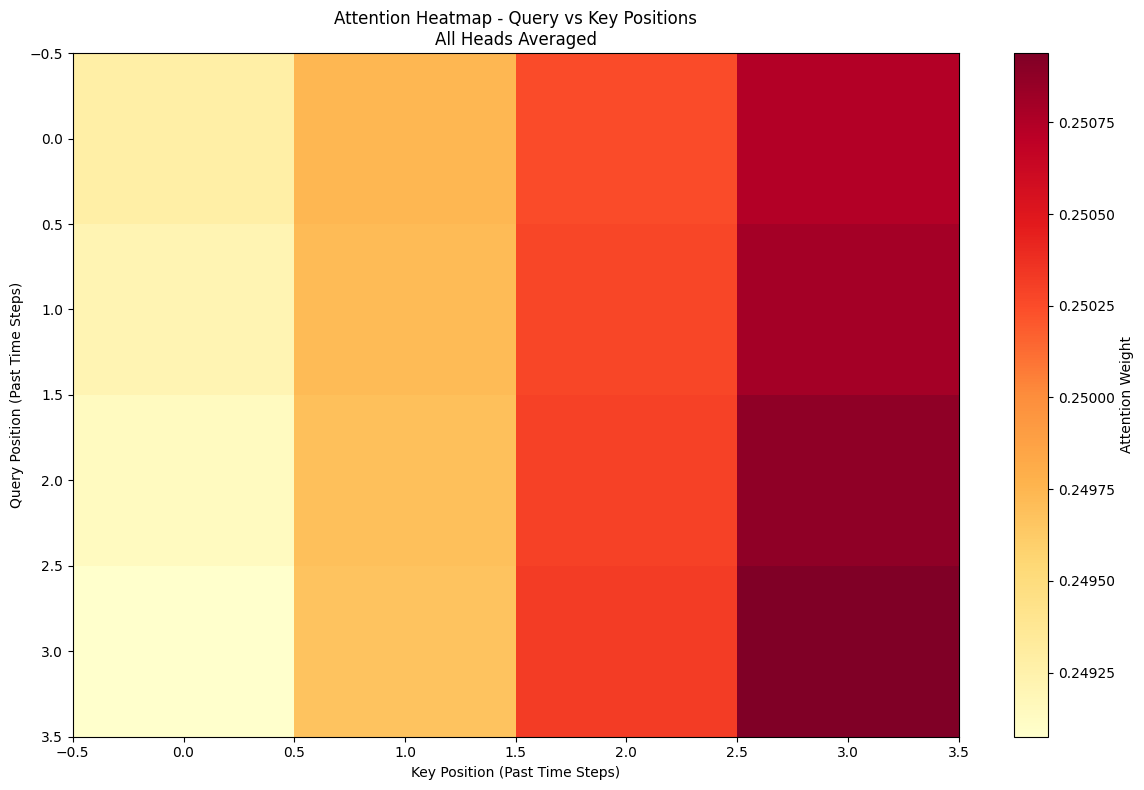


Attention heatmap shape: (4, 4)
(seq_len_query=4, seq_len_key=4)


In [ ]:
# Function to visualize attention weights from the Keras model
def visualize_attention_heatmap(model, X_test, sample_idx=0, head_idx=None, figsize=(10, 8)):
    """
    Visualize attention weights as heatmap for a test sample.
    Shows which query positions attend to which key positions.

    Args:
        model: trained LSTMAttentionModelKeras instance
        X_test: test data batch (batch_size, seq_len, input_size)
        sample_idx: which sample in batch to visualize
        head_idx: which attention head to visualize (None = average over all heads)
        figsize: figure size for plot
    """
    # Run forward pass to store attention weights
    _ = model(X_test, training=False)

    # Extract attention heatmap
    heatmap = model.get_attention_heatmap(sample_idx=0, head_idx=head_idx)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(heatmap, cmap='YlOrRd', aspect='auto')
    ax.set_xlabel('Key Position (Past Time Steps)')
    ax.set_ylabel('Query Position (Past Time Steps)')
    ax.set_title(f'Attention Heatmap - Query vs Key Positions\n{"All Heads Averaged" if head_idx is None else f"Head {head_idx}"}')
    plt.colorbar(im, ax=ax, label='Attention Weight')
    plt.tight_layout()
    plt.show()

    return heatmap

# Test visualization on a sample from validation set
# First prediction from validation set
test_sample = X_past_val[0][None, :, :]  # (1, seq_len, 4)
pred_lstm_attn = lstm_attn_model(test_sample, training=False).numpy()
print(f"LSTM-Attention prediction: {pred_lstm_attn[0]:.6f}")
print(f"Actual value: {y_test[0, 0]:.6f}")

# Visualize attention weights (query vs key positions)
attention_heatmap = visualize_attention_heatmap(
    lstm_attn_model, test_sample, sample_idx=0, head_idx=None,
    figsize=(12, 8)
)
print(f"\nAttention heatmap shape: {attention_heatmap.shape}")
print(f"(seq_len_query={attention_heatmap.shape[0]}, seq_len_key={attention_heatmap.shape[1]})")

The most recent time step clearly receives the most attention, which is expected in time series forecasting. Other past time steps get less and less attention as they are further in the past.

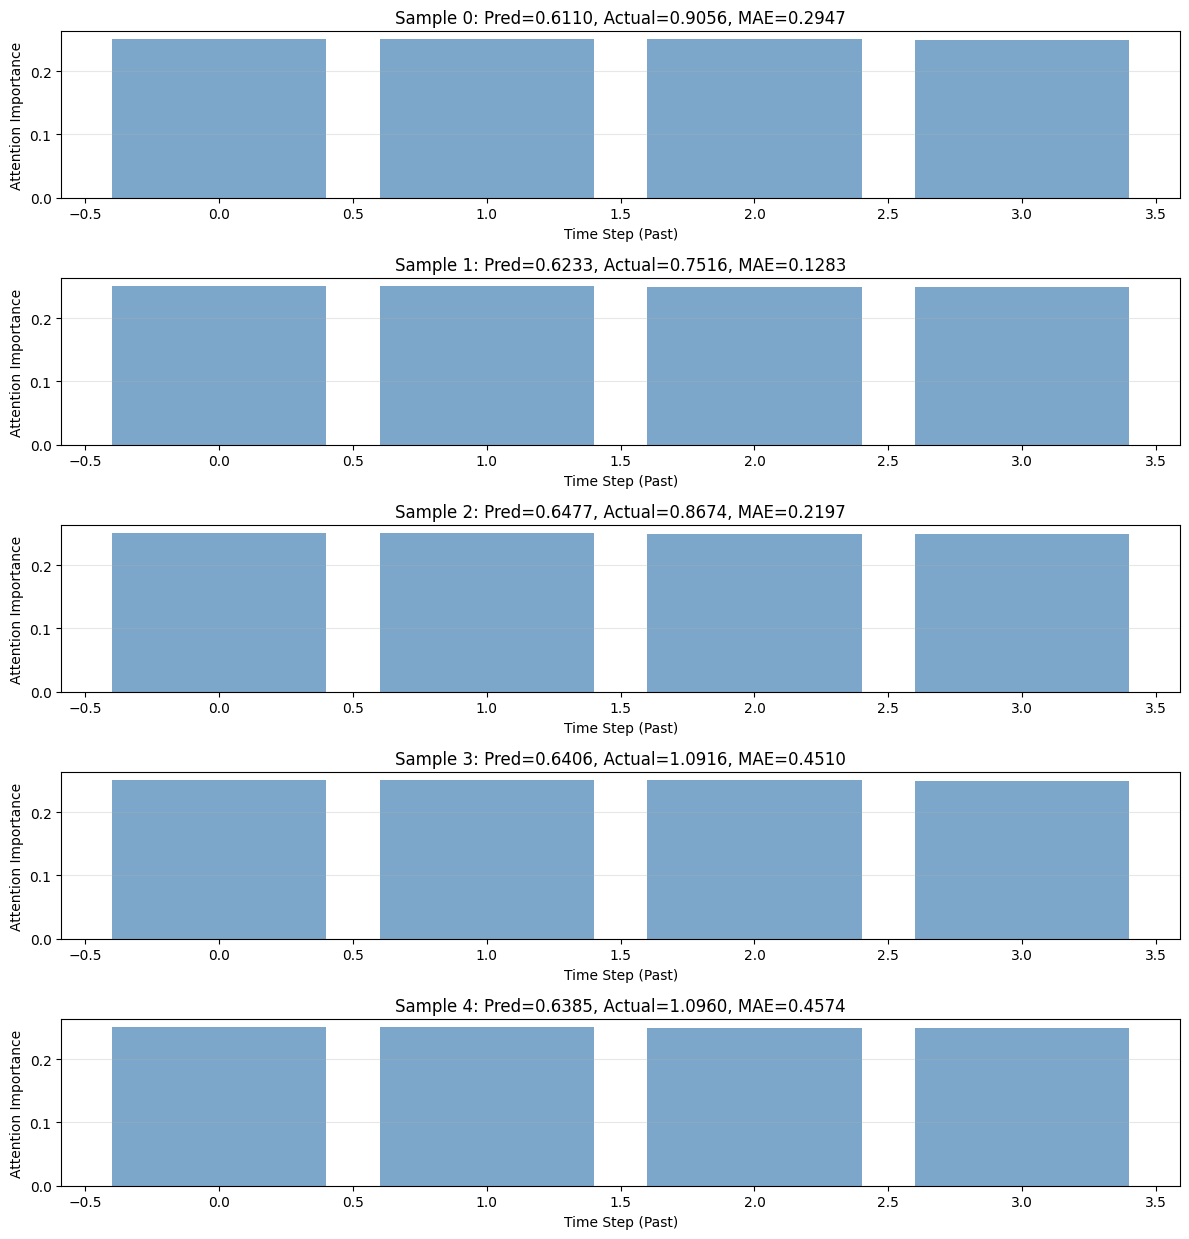


Attention Interpretation:
- Bar heights show which past time steps receive most attention
- Taller bars = more important for the current prediction
- Darker regions in heatmaps = stronger attention links between time steps


In [ ]:
# Detailed attention analysis
def analyze_attention_importance(model, X_test, sample_idx=0):
    """
    Analyze which past time steps are most important for predictions.
    Computes attention importance by averaging attention from each query position.

    Args:
        model: trained LSTMAttentionModelKeras instance
        X_test: test data batch (batch_size, seq_len, input_size)
        sample_idx: which sample in batch to analyze

    Returns:
        importance: (seq_len,) array of importance scores
    """
    # Run forward pass
    _ = model(X_test, training=False)

    # Get full attention weights (batch, num_heads, seq_q, seq_k)
    attn_weights = model.get_attention_weights()

    if attn_weights is None:
        raise ValueError("No attention weights available")

    weights = attn_weights.numpy()  # (batch, num_heads, seq_q, seq_k)
    sample_weights = weights[sample_idx]  # (num_heads, seq_q, seq_k)

    # Average over heads and query positions
    importance = np.mean(sample_weights, axis=(0, 1))  # (seq_k,)

    return importance

# Analyze attention for multiple test samples
n_samples = min(5, len(X_past_test))
fig, axes = plt.subplots(n_samples, 1, figsize=(12, 2.5*n_samples))
if n_samples == 1:
    axes = [axes]

for idx in range(n_samples):
    importance = analyze_attention_importance(lstm_attn_model, X_past_test[idx:idx+1])
    pred = lstm_attn_model(X_past_test[idx:idx+1], training=False).numpy()[0]
    actual = y_test[idx, 0]

    axes[idx].bar(range(len(importance)), importance, color='steelblue', alpha=0.7)
    axes[idx].set_xlabel('Time Step (Past)')
    axes[idx].set_ylabel('Attention Importance')
    axes[idx].set_title(f'Sample {idx}: Pred={pred:.4f}, Actual={actual:.4f}, MAE={abs(pred-actual):.4f}')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAttention Interpretation:")
print("- Bar heights show which past time steps receive most attention")
print("- Taller bars = more important for the current prediction")
print("- Darker regions in heatmaps = stronger attention links between time steps")

## Problem 4.3: Temporal Fusion Transformer (25 points)
Use PyTorch Forecasting library:

• Apply TFT to a retail sales forecasting problem.

• Include static features (store location) and time-varying features (promo-
tions, holidays).

• Analyze variable importance from the model.

• Generate probabilistic forecasts with quantile predictions.

In [2]:
!pip install pytorch-forecasting

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
import lightning.pytorch as pl

Walmart Sales Forecasting (Weekly sales focasting for 45 Walmart stores across 99 departments)

Index:
- Store
- Date
- Department

Features:
- IsHoliday (whether the week is a holiday week)
- Temperature (average temperature in the region)
- Fuel_Price (cost of fuel in the region)
- CPI (consumer price index)
- Unemployment (unemployment rate in the region)
- Type (type of store: A, B, C)
- Size (size of the store in square feet)

Target:
- Weekly_Sales (sales for the given department in the given store and week)

In [3]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
features = pd.read_csv("data/features.csv")
features = features[["Store", "Date", "Temperature", "Fuel_Price", "CPI", "Unemployment"]]
stores = pd.read_csv("data/stores.csv")

In [ ]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [ ]:
features.head()

,Store,Date,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,42.31,2.572,211.096358,8.106
1,1,2010-02-12,38.51,2.548,211.242170,8.106
2,1,2010-02-19,39.93,2.514,211.289143,8.106
3,1,2010-02-26,46.63,2.561,211.319643,8.106
4,1,2010-03-05,46.50,2.625,211.350143,8.106


In [ ]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [4]:
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])
features["Date"] = pd.to_datetime(features["Date"])

# merge additional features into train and test
train = train.merge(features, on=["Store", "Date"], how="left")
train = train.merge(stores, on="Store", how="left")
test = test.merge(features, on=["Store", "Date"], how="left")
test = test.merge(stores, on="Store", how="left")

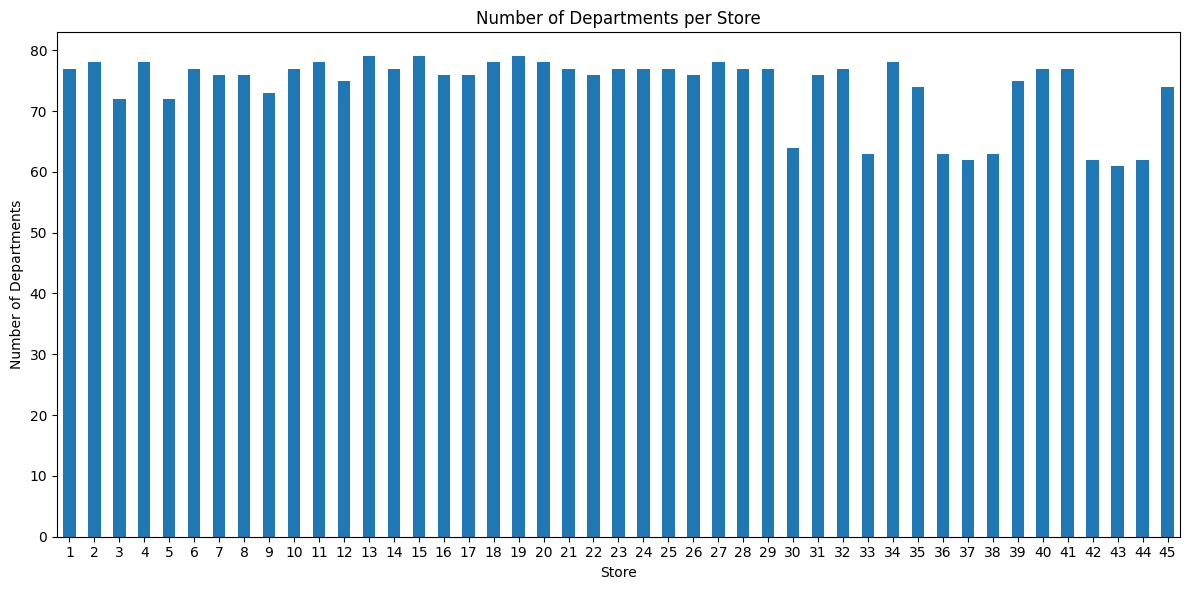

In [ ]:
plt.figure(figsize=(12, 6))
train.groupby("Store")["Dept"].nunique().plot(kind="bar", figsize=(12, 6))
plt.title("Number of Departments per Store")
plt.xlabel("Store")
plt.ylabel("Number of Departments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The dataset is rather well populated as for each store there is no less than 60 departments.

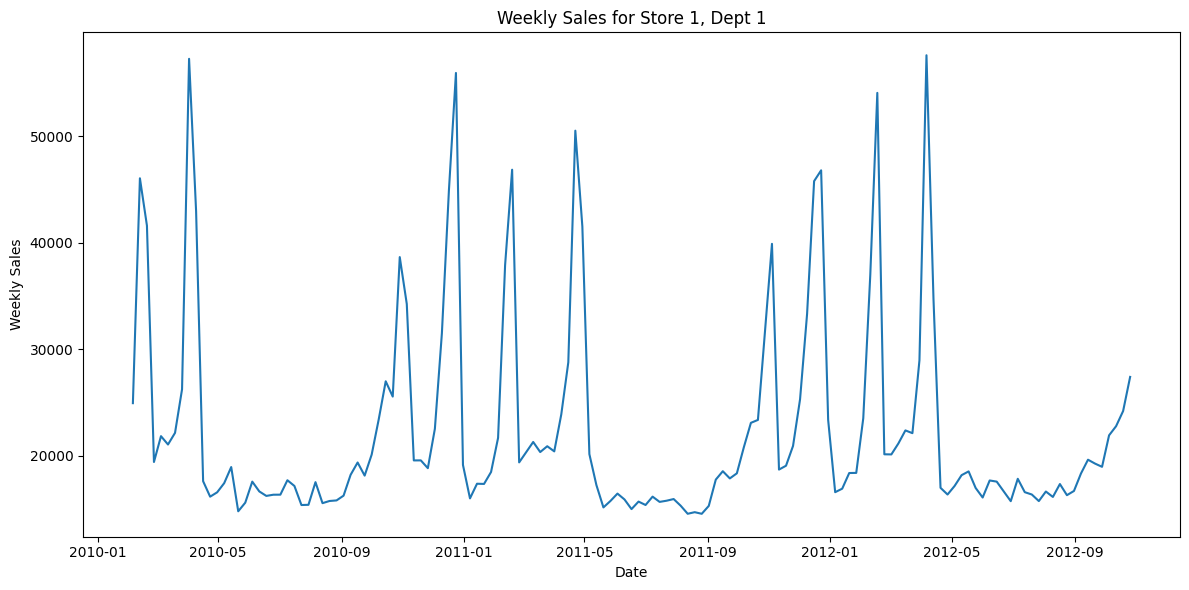

In [ ]:

plt.figure(figsize=(12, 6))
sns.lineplot(data=train[(train.Store == 1) & (train.Dept == 1)], x="Date", y="Weekly_Sales")
plt.title("Weekly Sales for Store 1, Dept 1")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

Sales time series exhibits occasional spikes, which can be attributed to promotions or holidays. The model should be able to capture these patterns to make accurate forecasts.

In [ ]:
# time index has to be an integer, not datetime
train["Week"] = (train["Date"] - train["Date"].min()).dt.days // 7
train.drop(columns=["Date"], inplace=True)

# TimeSeriesDataset treats bools as reals, so convert to category
train["IsHoliday"] = train["IsHoliday"].astype("str").astype("category")

In [6]:
# narrow it down to 200 Store Dept combinations for faster experimentation

keys = train[["Store", "Dept"]].drop_duplicates()
sampled_keys = keys.sample(n=200, random_state=42)
train_sampled = train.merge(sampled_keys, on=["Store", "Dept"], how="inner")
test_sampled = test.merge(sampled_keys, on=["Store", "Dept"], how="inner")

In [ ]:
pl.seed_everything(42, workers=True)

MAX_ENC = 3 #look-back window (sequence length)
MAX_PRED = 1 #forecasting horizon
cutoff = int(train["Week"].quantile([0.9]).iloc[0])

training = TimeSeriesDataSet(
    train[train.Week <= cutoff], #slice of full dataset to be training set
    time_idx              = "Week", #time_idx column
    target                = "Weekly_Sales", #target column
    group_ids             = ["Store", "Dept"], #columns that uniquely identify different time series (e.g. different stores)
    max_encoder_length    = MAX_ENC,
    max_prediction_length = MAX_PRED,

    #specifying which features belong to which 'categories'
    time_varying_known_categoricals  = ["IsHoliday"],
    time_varying_unknown_reals       = ["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment"],
    static_categoricals= ["Type"],
    static_reals= ["Size"],

    #it's good to normalize data separately for each group to handle different scales (e.g. small and large stores)
    target_normalizer = GroupNormalizer(groups=["Store", "Dept"]),
    allow_missing_timesteps=True
)

validation = TimeSeriesDataSet.from_dataset( #validation set (here defined a bit different than in the lecture)
    training, train, predict=False, min_prediction_idx = cutoff+1, stop_randomization=True
)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 119 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__Store': 1, '__group_id__Dept': 77}, {'__group_id__Store': 2, '__group_id__Dept': 77}, {'__group_id__Store': 2, '__group_id__Dept': 78}, {'__group_id__Store': 3, '__group_id__Dept': 77}, {'__group_id__Store': 3, '__group_id__Dept': 78}, {'__group_id__Store': 3, '__group_id__Dept': 83}, {'__group_id__Store': 4, '__group_id__Dept': 39}, {'__group_id__Store': 5, '__group_id__Dept': 77}, {'__group_id__Store': 5, '__group_id__Dept': 78}, {'__group_id__Store': 5, '__group_id__Dept': 80}]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/py

In [9]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate          = 0.01, #you can also try 0.0001, 0.01 etc, professional way: lr_find()
    hidden_size            = 32,   #start with 16/32, increase if not enough
    attention_head_size    = 4,    #usually 1-4
    dropout                = 0.2, #usually 0.1-0.3
    hidden_continuous_size = 16,   #set to <= hidden_size
    loss                   = QuantileLoss() #loss function for generating probabilistic forecasts
)

In [ ]:
csv_logger = pl.loggers.CSVLogger(save_dir="logs", name="my_tft_model")
#to log train/val losses - stored later e.g. in logs/my_tft_model/version_0/metrics.csv
#from this file, you can select "train_loss_epoch" and "val_loss" columns to plot train/val loss curves

trainer = pl.Trainer(
    max_epochs        = 19,
    gradient_clip_val = 0.1, #gradient clipping
    accelerator       = "gpu", #<------"gpu" if GPU is available, else "cpu"
    log_every_n_steps = 5,
    enable_progress_bar = True,
    logger            = csv_logger,
    enable_checkpointing = False,
    #you can also consider using callbacks like EarlyStopping or ModelCheckpoint <- professional standard
)
trainer.fit(
    tft,
    train_dataloaders = training.to_dataloader(train=True,  batch_size=256), #other batch_sizes may be better for your case (32, 128)
    val_dataloaders   = validation.to_dataloader(train=False, batch_size=256),
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     11 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    192 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  2.0 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 10.1 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │     96 │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 65.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 65.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 250                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/metrics/base_metrics/_base_metrics.py:906: UserWarning:
Loss is not finite. Resetting it to 1e9
  warnings.warn("Loss is not finite. Resetting it to 1e9")

INFO: `Trainer.fit` stopped: `max_epochs=5` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


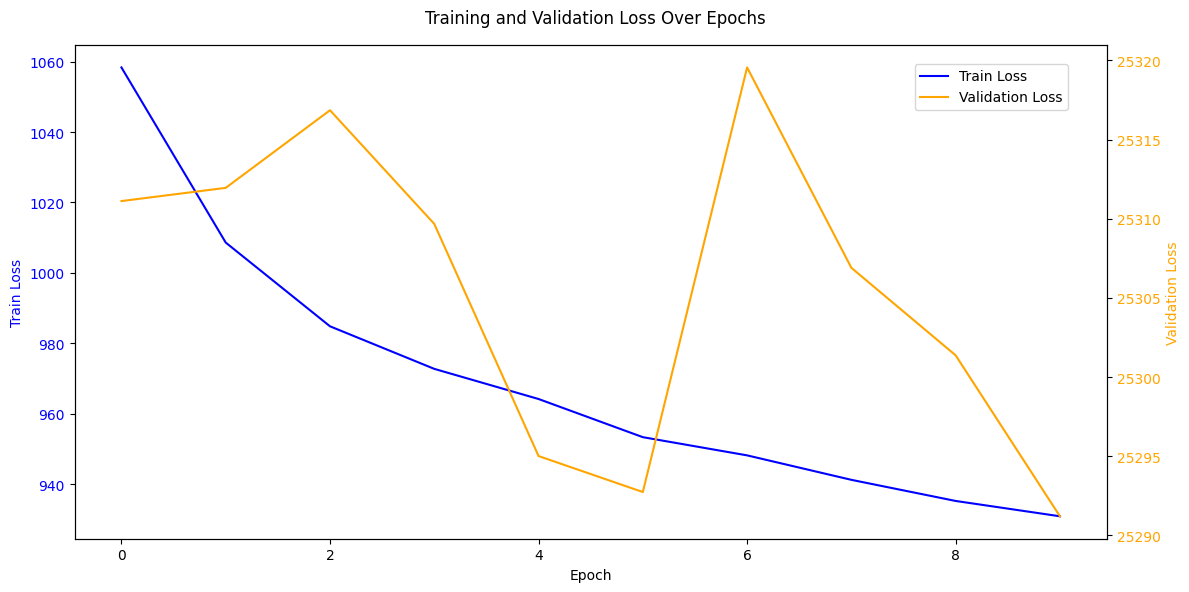

In [ ]:
metrics = pd.read_csv("data/metrics.csv")
train_loss = metrics[metrics.train_loss_epoch.notna()][["epoch", "train_loss_epoch"]]
val_loss = metrics[metrics.val_loss.notna()][["epoch", "val_loss"]]

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(train_loss["epoch"], train_loss["train_loss_epoch"], label="Train Loss", color="blue")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Loss", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")    
ax2 = ax1.twinx()
ax2.plot(val_loss["epoch"], val_loss["val_loss"], label="Validation Loss", color="orange")
ax2.set_ylabel("Validation Loss", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")  
fig.suptitle("Training and Validation Loss Over Epochs")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.show()

Model convergence is not possible with this amount of epochs and only two hours of training time.

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

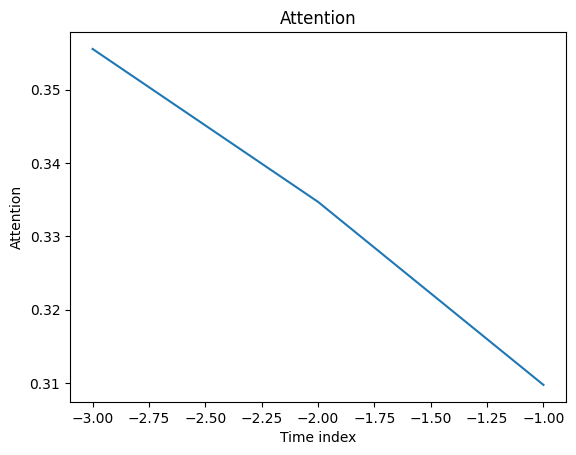

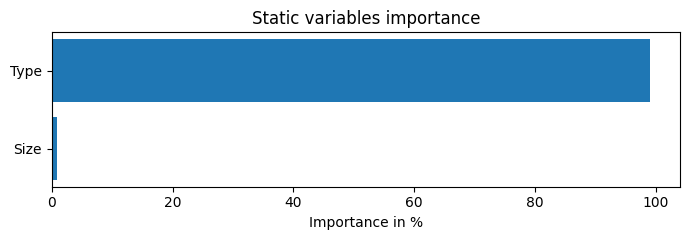

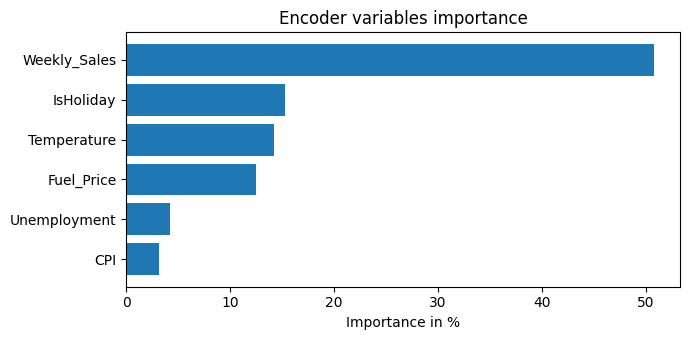

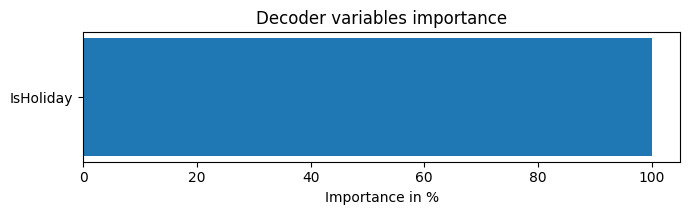

In [42]:
raw_preds = tft.predict(validation, mode="raw", return_x=True)
interpretation = tft.interpret_output(raw_preds.output, reduction="sum")
tft.plot_interpretation(interpretation)
plt.tight_layout(); plt.show()

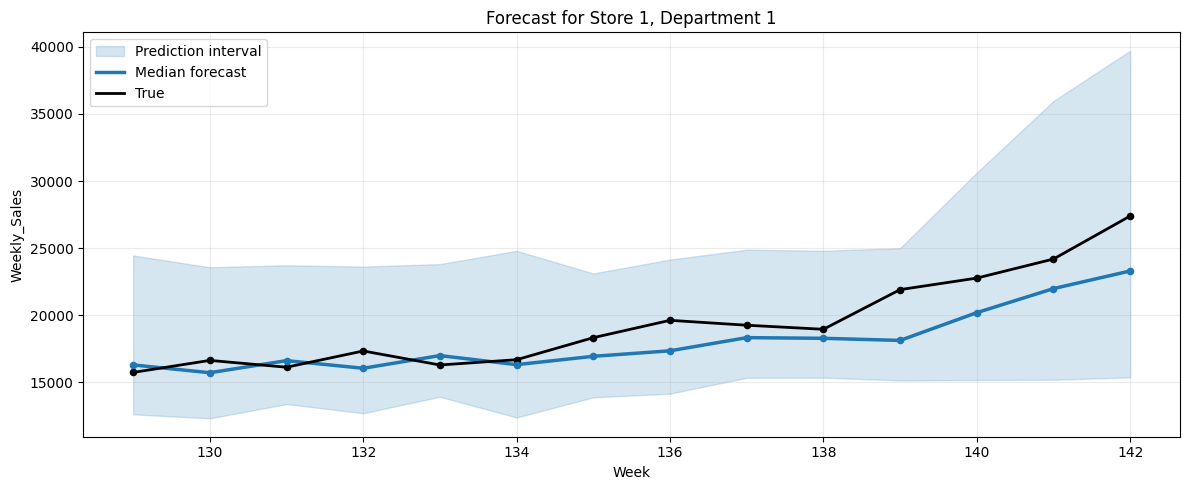

In [ ]:
pred_index = validation.x_to_index(raw_preds.x)

mask = (pred_index.Store == 1) & (pred_index.Dept == 1)

group_true = raw_preds.x["decoder_target"][mask]

# all prediction windows for that group
group_preds = raw_preds.output.prediction[mask]
group_index = pred_index.loc[mask]

pred_1step = group_preds[:, 0].detach().cpu().numpy()
true_1step = group_true[:, 0].detach().cpu().numpy()

median = pred_1step[:, 3]
lower = pred_1step[:, 0]
upper = pred_1step[:, -1]

x_labels = group_index.Week.values.astype(int)

plt.figure(figsize=(12, 5))

# uncertainty band
plt.fill_between(
    x_labels,
    lower,
    upper,
    color="tab:blue",
    alpha=0.18,
    label="Prediction interval"
)

# median forecast
plt.plot(
    x_labels,
    median,
    color="tab:blue",
    linewidth=2.5,
    label="Median forecast"
)

# true values
plt.plot(
    x_labels,
    true_1step,
    color="black",
    linewidth=2,
    label="True"
)

plt.scatter(x_labels, true_1step, color="black", s=20, zorder=3)
plt.scatter(x_labels, median, color="tab:blue", s=20, zorder=3)

plt.title(f"Forecast for Store 1, Department 1")
plt.xlabel("Week")
plt.ylabel("Weekly_Sales")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

Predictions are however plausible, with the model capturing the general trend and seasonality in the data. Unfortunately, we do not observe spikes in sales on the test set, therefore we cannot analyze the model's ability to capture these patterns. Variable importance analysis shows that the most important features are Weekly_Sales, IsHoliday, and Temperature, which makes sense given the nature of the problem. Quantile predictions provide a range of possible outcomes, which can be useful for decision-making under uncertainty.

## Problem 4.4: Model Comparison (20 points)
Comprehensive evaluation of time series models:

• Compare ARIMA, Prophet, LSTM, and TFT on same dataset.

• Evaluate using RMSE, MAE, and MAPE.

• Analyze computational costs.

• Provide recommendations for different use cases.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.callbacks import EarlyStopping

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
import prophet

from sklearn.preprocessing import OneHotEncoder

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
import lightning.pytorch as pl

import time
import tracemalloc

In [480]:
seed = 42
set_reproducible_seed(seed)

We focused on the one-step-ahead prediction case for the energy demand data used in problem 1.

In [555]:
train = pd.read_csv("data/residential4_energy_demand_daily_train.csv", index_col=0, parse_dates=True)
test = pd.read_csv("data/residential4_energy_demand_daily_test.csv", index_col=0, parse_dates=True)

train.head()

,energy_demand,dishwasher,ev,freezer,grid_export,heat_pump,pv,washing_machine,temperature,radiation_direct_horizontal,radiation_diffuse_horizontal,is_holiday_or_weekend,season
utc_timestamp,,,,,,,,,,,,,
2015-10-14 00:00:00+00:00,8.733000,0.009458,3.801208,0.344667,4.847500,6.491625,9.906250,0.004542,3.088417,5.377025,55.964250,False,autumn
2015-10-15 00:00:00+00:00,8.840375,0.473000,3.952000,0.509542,4.565792,5.277917,10.963958,0.006667,3.882417,1.886054,43.256808,False,autumn
2015-10-16 00:00:00+00:00,13.924917,0.468375,2.327250,0.498083,2.365208,10.344583,6.637250,0.004750,4.813750,1.658937,41.459929,False,autumn
2015-10-17 00:00:00+00:00,16.025792,0.009917,4.115250,0.495875,2.849958,11.119208,7.825333,0.004750,5.372500,16.392312,62.422004,True,autumn
2015-10-18 00:00:00+00:00,17.262167,0.581167,5.184708,0.492042,1.611875,10.978875,6.890042,0.007833,5.974083,16.178633,60.851612,True,autumn


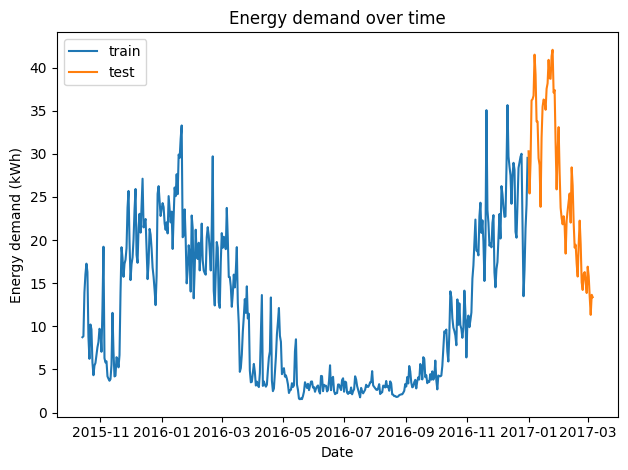

In [483]:
plt.plot(train.index, train["energy_demand"])
plt.plot(test.index, test["energy_demand"])
plt.legend(["train", "test"])
plt.xlabel("Date")
plt.ylabel("Energy demand (kWh)")
plt.title("Energy demand over time")
plt.tight_layout()
plt.show()


In [490]:
# dict for storing time, memory and performance metrics for each model
results = {
    "Univariate LSTM": {},
    "ARIMA": {},
    "Prophet": {},
    "TFT": {},
}

In [491]:
# arima fit
history = train["energy_demand"].copy().tolist()
arima_preds = []
fitted_values = []
tracemalloc.start()
start_time = time.time()
for i in range(len(test)):
    decomp = seasonal_decompose(history, model="additive", period=7, extrapolate_trend="freq")
    deseasonalized = history - decomp.seasonal
    seasonal_cycle = decomp.seasonal[:7]
    arima = ARIMA(deseasonalized, order=(1,1,2)).fit()
    y_hat = arima.forecast()[0] + seasonal_cycle[len(history) % 7]
    arima_preds.append(y_hat)
    history.append(test["energy_demand"].iloc[i])
    if i == 0:
        fitted_values = arima.fittedvalues + decomp.seasonal[:len(arima.fittedvalues)]
end_time = time.time()
arima_timing = end_time - start_time
print(f"ARIMA fitting and forecasting took {arima_timing:.2f} seconds")
current, peak = tracemalloc.get_traced_memory()
print(f"ARIMA memory usage: {current / 1024 / 1024:.2f} MB")
print(f"ARIMA peak memory usage: {peak / 1024 / 1024:.2f} MB")
tracemalloc.stop()

results["ARIMA"]["time"] = arima_timing
results["ARIMA"]["memory"] = current
results["ARIMA"]["peak_memory"] = peak
results["ARIMA"]["preds"] = arima_preds

ARIMA fitting and forecasting took 3.25 seconds
ARIMA memory usage: 1.71 MB
ARIMA peak memory usage: 3.30 MB


In [492]:
# prophet fit
cat_cols = ['is_holiday_or_weekend', 'season']

train_target = train[["energy_demand"]]
test_target = test[["energy_demand"]]

train_cat = train[cat_cols]
test_cat = test[cat_cols]

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

train_cat_encoded = encoder.fit_transform(train_cat)
test_cat_encoded = encoder.transform(test_cat)

encoded_cols = encoder.get_feature_names_out(cat_cols)

train_cat_df = pd.DataFrame(train_cat_encoded, columns=encoded_cols, index=train.index)
test_cat_df = pd.DataFrame(test_cat_encoded, columns=encoded_cols, index=test.index)

train_final = pd.concat([train_target, train_cat_df], axis=1)
test_final = pd.concat([test_target, test_cat_df], axis=1)

train_final = train_final.reset_index().rename(columns={'utc_timestamp': 'ds', 'energy_demand': 'y'})
train_final['ds'] = train_final['ds'].dt.tz_localize(None)
test_final = test_final.reset_index().rename(columns={'utc_timestamp': 'ds', 'energy_demand': 'y'})
test_final['ds'] = test_final['ds'].dt.tz_localize(None)

regressor_cols = train_final.columns.difference(['ds', 'y'])
_train_df = train_final.copy()
rows = []
prophet_preds = []

tracemalloc.start()
start_time = time.time()

for i in range(len(test_final)):

    m = prophet.Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)

    for col in regressor_cols:
        m.add_regressor(col)

    m.fit(_train_df)

    _train_df = pd.concat([_train_df, test_final.iloc[i:i+1]], ignore_index=True)
    future = _train_df.drop(columns=['y'])

    forecast = m.predict(future)
    next_row = forecast.iloc[-1]
    rows.append(next_row)
    prophet_preds.append(next_row['yhat'])
end_time = time.time()
prophet_timing = end_time - start_time
print(f"Prophet fitting and forecasting took {prophet_timing:.2f} seconds")
current, peak = tracemalloc.get_traced_memory()
print(f"Prophet memory usage: {current / 1024 / 1024:.2f} MB")
print(f"Prophet peak memory usage: {peak / 1024 / 1024:.2f} MB")
tracemalloc.stop()

results["Prophet"]["time"] = prophet_timing
results["Prophet"]["memory"] = current
results["Prophet"]["peak_memory"] = peak
results["Prophet"]["preds"] = prophet_preds

18:04:09 - cmdstanpy - INFO - Chain [1] start processing
18:04:09 - cmdstanpy - INFO - Chain [1] done processing
18:04:09 - cmdstanpy - INFO - Chain [1] start processing
18:04:09 - cmdstanpy - INFO - Chain [1] done processing
18:04:09 - cmdstanpy - INFO - Chain [1] start processing
18:04:09 - cmdstanpy - INFO - Chain [1] done processing
18:04:09 - cmdstanpy - INFO - Chain [1] start processing
18:04:09 - cmdstanpy - INFO - Chain [1] done processing
18:04:09 - cmdstanpy - INFO - Chain [1] start processing
18:04:09 - cmdstanpy - INFO - Chain [1] done processing
18:04:10 - cmdstanpy - INFO - Chain [1] start processing
18:04:10 - cmdstanpy - INFO - Chain [1] done processing
18:04:10 - cmdstanpy - INFO - Chain [1] start processing
18:04:10 - cmdstanpy - INFO - Chain [1] done processing
18:04:10 - cmdstanpy - INFO - Chain [1] start processing
18:04:10 - cmdstanpy - INFO - Chain [1] done processing
18:04:10 - cmdstanpy - INFO - Chain [1] start processing
18:04:10 - cmdstanpy - INFO - Chain [1]

Prophet fitting and forecasting took 12.69 seconds
Prophet memory usage: 0.89 MB
Prophet peak memory usage: 17.17 MB


In [497]:
X_past_train, y_train, X_past_val, y_val, X_past_test, y_test = create_sequences(train_df, val_df, test_df, k=1, f=1)

univariate_lstm = Sequential()
univariate_lstm.add(LSTM(100, activation="relu", input_shape=(30, 1)))
univariate_lstm.add(Dense(1))
univariate_lstm.compile(optimizer="adam", loss="mse")
early_stopping = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

tracemalloc.start()
start_time = time.time()

history = univariate_lstm.fit(
    X_past_train[:, -1:, 0], y_train,
    validation_data=(X_past_val[:, -1:, 0], y_val),
    epochs=100,
    batch_size=8,
    callbacks=[early_stopping],
    verbose=0
)

preds = univariate_lstm.predict(X_past_test[:, -1:, 0]).flatten()
preds_rescaled = scaler.inverse_transform(np.hstack([preds.reshape(-1, 1), np.zeros((preds.size, train_df.shape[1]-1))]))[:, 0]

end_time = time.time()
univariate_lstm_timing = end_time - start_time
print(f"Univariate LSTM fitting and forecasting took {univariate_lstm_timing:.2f} seconds")

current, peak = tracemalloc.get_traced_memory()
print(f"Univariate LSTM memory usage: {current / 1024 / 1024:.2f} MB")
print(f"Univariate LSTM peak memory usage: {peak / 1024 / 1024:.2f} MB")
tracemalloc.stop()

results["Univariate LSTM"]["time"] = univariate_lstm_timing
results["Univariate LSTM"]["memory"] = current
results["Univariate LSTM"]["peak_memory"] = peak
results["Univariate LSTM"]["preds"] = preds_rescaled

/Users/tomasz/PycharmProjects/ML_labs/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1778342868.813079 15033617 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step

E0000 00:00:1778342882.395062 15033617 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Univariate LSTM fitting and forecasting took 14.08 seconds
Univariate LSTM memory usage: 4.14 MB
Univariate LSTM peak memory usage: 4.20 MB


In [556]:
# data transformations for TFT
train = train.reset_index()
test = test.reset_index()

timestamps = pd.concat([train['utc_timestamp'], test['utc_timestamp']])

train['day'] = (train['utc_timestamp'] - train['utc_timestamp'].min()).dt.days
test['day'] = (test['utc_timestamp'] - train['utc_timestamp'].min()).dt.days
train.drop(columns=['utc_timestamp'], inplace=True)
test.drop(columns=['utc_timestamp'], inplace=True)

train["is_holiday_or_weekend"] = train["is_holiday_or_weekend"].astype("str").astype("category")
test["is_holiday_or_weekend"] = test["is_holiday_or_weekend"].astype("str").astype("category")

train["group_id"] = 0
test["group_id"] = 0

cnct = pd.concat([train, test], ignore_index=True)
cnct

,energy_demand,dishwasher,ev,freezer,grid_export,heat_pump,pv,washing_machine,temperature,radiation_direct_horizontal,radiation_diffuse_horizontal,is_holiday_or_weekend,season,day,group_id
0,8.733000,0.009458,3.801208,0.344667,4.847500,6.491625,9.906250,0.004542,3.088417,5.377025,55.964250,False,autumn,0,0
1,8.840375,0.473000,3.952000,0.509542,4.565792,5.277917,10.963958,0.006667,3.882417,1.886054,43.256808,False,autumn,1,0
2,13.924917,0.468375,2.327250,0.498083,2.365208,10.344583,6.637250,0.004750,4.813750,1.658937,41.459929,False,autumn,2,0
3,16.025792,0.009917,4.115250,0.495875,2.849958,11.119208,7.825333,0.004750,5.372500,16.392312,62.422004,True,autumn,3,0
4,17.262167,0.581167,5.184708,0.492042,1.611875,10.978875,6.890042,0.007833,5.974083,16.178633,60.851612,True,autumn,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505,15.813333,0.377208,4.075958,0.333583,18.372208,14.502667,28.221250,0.310708,4.735292,32.137675,67.140725,False,spring,505,0
506,13.449167,0.000542,4.531500,0.330583,29.795458,11.842708,40.393083,0.640292,4.629875,16.933821,67.098783,False,spring,506,0
507,11.324375,0.000917,1.820792,0.332333,22.419250,12.796292,29.509250,0.003375,7.565042,50.082358,60.750250,True,spring,507,0
508,13.648833,0.510125,4.031958,0.338583,19.941750,13.975250,30.190292,0.004333,5.728208,40.675050,66.162454,True,spring,508,0


In [534]:
pl.seed_everything(42, workers=True)

MAX_ENC = 3 #look-back window (sequence length)
MAX_PRED = 1 #forecasting horizon

training = TimeSeriesDataSet(
    train, #slice of full dataset to be training set
    time_idx              = "day", #time_idx column
    target                = "energy_demand", #target column
    group_ids             = ["group_id"], #columns that uniquely identify different time series (e.g. different stores)
    max_encoder_length    = MAX_ENC,
    max_prediction_length = MAX_PRED,

    #specifying which features belong to which 'categories'
    time_varying_known_categoricals  = ["season", "is_holiday_or_weekend"],
    time_varying_unknown_reals       = [
        "energy_demand",
        "dishwasher", 
        "ev", 
        "freezer", 
        "grid_export", 
        "heat_pump", 
        "washing_machine", 
        "temperature", 
        "radiation_direct_horizontal", 
        "radiation_diffuse_horizontal"
    ],
    #it's good to normalize data separately for each group to handle different scales (e.g. small and large stores)
    target_normalizer = GroupNormalizer(groups=["group_id"]),
)

validation = TimeSeriesDataSet.from_dataset( #validation set (here defined a bit different than in the lecture)
    training, cnct, predict=False, min_prediction_idx = test.at[0, "day"], stop_randomization=True
)

Seed set to 42


In [535]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate          = 0.01, #you can also try 0.0001, 0.01 etc, professional way: lr_find()
    hidden_size            = 32,   #start with 16/32, increase if not enough
    attention_head_size    = 1,    #usually 1-4
    dropout                = 0.2, #usually 0.1-0.3
    hidden_continuous_size = 16,   #set to <= hidden_size
    loss                   = QuantileLoss() #loss function for generating probabilistic forecasts
)

/Users/tomasz/PycharmProjects/ML_labs/venv/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/Users/tomasz/PycharmProjects/ML_labs/venv/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [601]:
csv_logger = pl.loggers.CSVLogger(save_dir="logs", name="my_tft_model")
#to log train/val losses - stored later e.g. in logs/my_tft_model/version_0/metrics.csv
#from this file, you can select "train_loss_epoch" and "val_loss" columns to plot train/val loss curves

trainer = pl.Trainer(
    max_epochs        = 50,
    gradient_clip_val = 0.01, #gradient clipping
    accelerator       = "gpu", #<------"gpu" if GPU is available, else "cpu"
    log_every_n_steps = 5,
    enable_progress_bar = True,
    logger            = csv_logger,
    enable_checkpointing = False,
    callbacks=[
        pl.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            # restore_best_weights=True
        )
    ],
)

tracemalloc.start()
start_time = time.time()

trainer.fit(
    tft,
    train_dataloaders = training.to_dataloader(train=True,  batch_size=8), #other batch_sizes may be better for your case (32, 128)
    val_dataloaders   = validation.to_dataloader(train=False, batch_size=8),
)

raw_preds = tft.predict(validation, mode="raw", return_x=True)

end_time = time.time()
tft_timing = end_time - start_time
print(f"TFT fitting and forecasting took {tft_timing:.2f} seconds") 
current, peak = tracemalloc.get_traced_memory()
print(f"TFT memory usage: {current / 1024 / 1024:.2f} MB")
print(f"TFT peak memory usage: {peak / 1024 / 1024:.2f} MB")
tracemalloc.stop()

results["TFT"]["time"] = tft_timing
results["TFT"]["memory"] = current
results["TFT"]["peak_memory"] = peak

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     14 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    320 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │      0 │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 21.3 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │    294 │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  4.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 76.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 76.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 309                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/tomasz/PycharmProjects/ML_labs/venv/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/Users/tomasz/PycharmProjects/ML_labs/venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_c
onnector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the
value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/Users/tomasz/PycharmProjects/ML_labs/venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_c
onnector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/tomasz/PycharmProjects/ML_labs/venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


TFT fitting and forecasting took 194.04 seconds
TFT memory usage: 1.27 MB
TFT peak memory usage: 1.59 MB


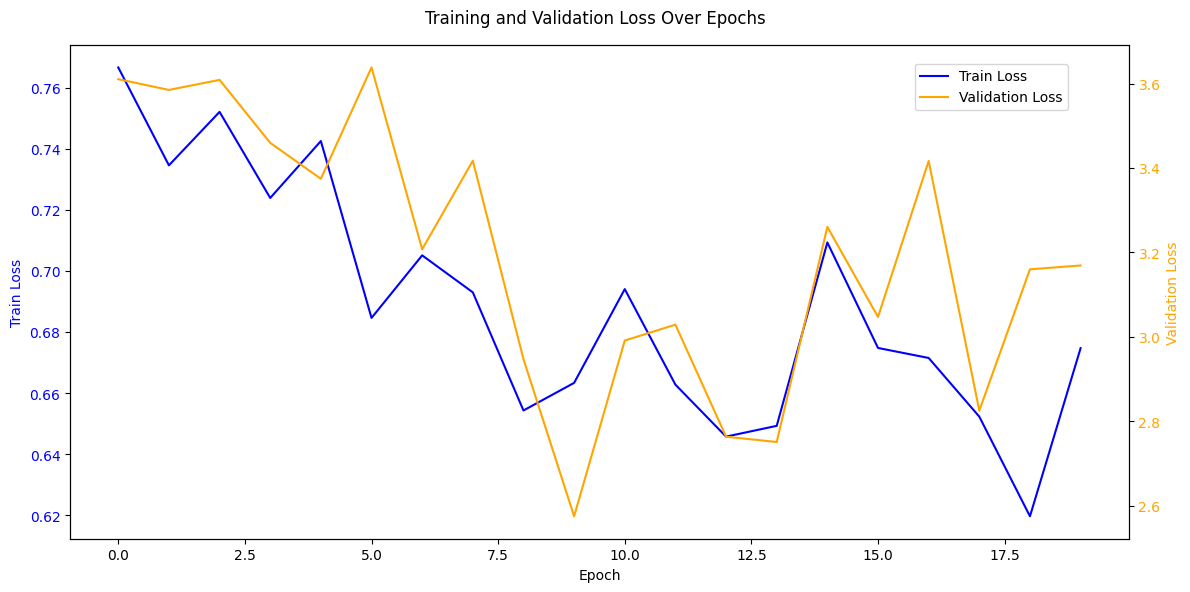

In [605]:
metrics = pd.read_csv("logs/my_tft_model/version_3/metrics.csv")
train_loss = metrics[metrics.train_loss_epoch.notna()][["epoch", "train_loss_epoch"]]
val_loss = metrics[metrics.val_loss.notna()][["epoch", "val_loss"]]

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(train_loss["epoch"], train_loss["train_loss_epoch"], label="Train Loss", color="blue")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Loss", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")    
ax2 = ax1.twinx()
ax2.plot(val_loss["epoch"], val_loss["val_loss"], label="Validation Loss", color="orange")
ax2.set_ylabel("Validation Loss", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")  
fig.suptitle("Training and Validation Loss Over Epochs")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.show()

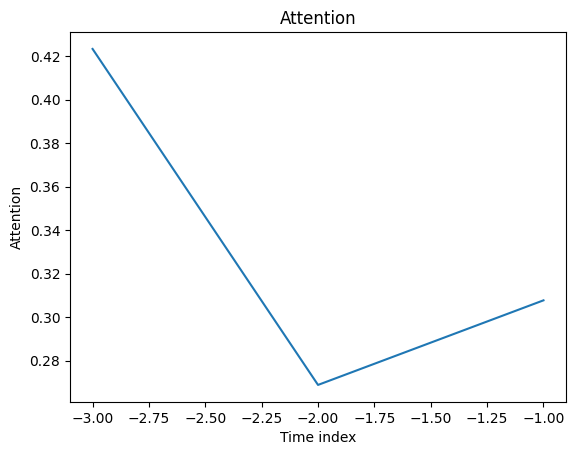

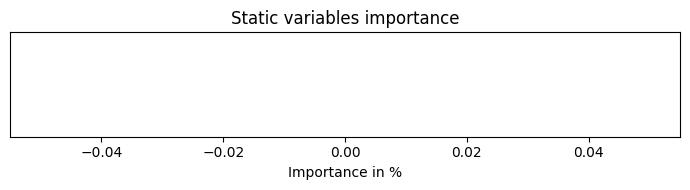

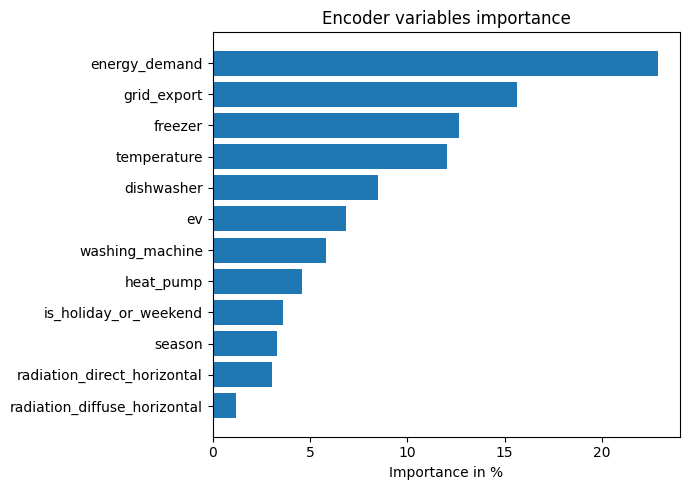

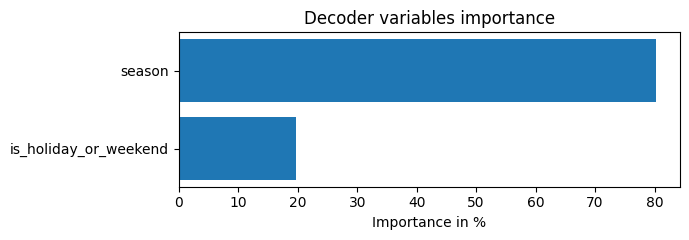

In [606]:
interpretation = tft.interpret_output(raw_preds.output, reduction="sum")
tft.plot_interpretation(interpretation)
plt.tight_layout(); plt.show()

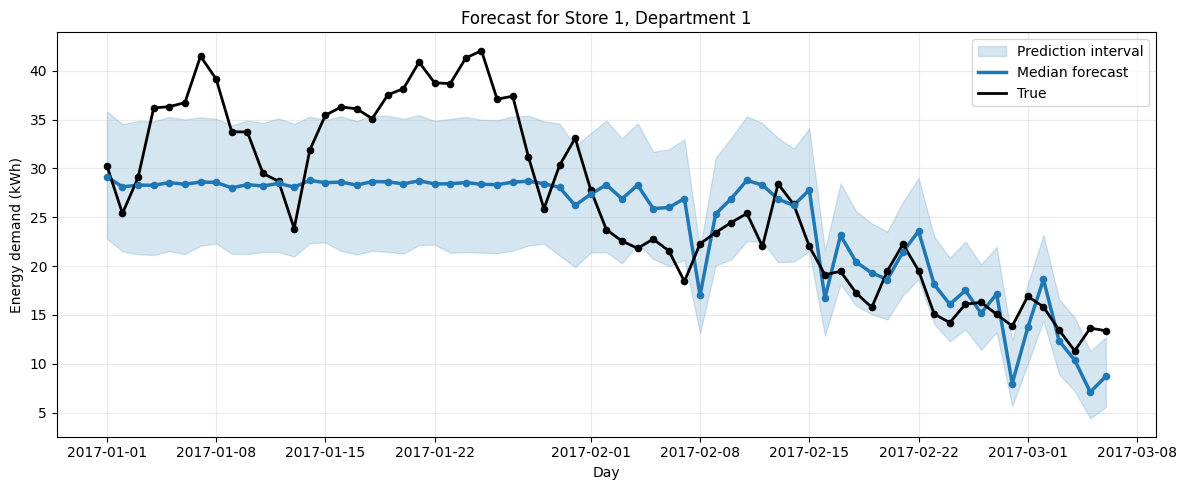

In [607]:
pred_index = validation.x_to_index(raw_preds.x)

true = raw_preds.x["decoder_target"]

# all prediction windows for that group
preds = raw_preds.output.prediction
index = pred_index

pred_1step = preds[:, 0].detach().cpu().numpy()
true_1step = true[:, 0].detach().cpu().numpy()

median = pred_1step[:, 3]
results["TFT"]["preds"] = median
lower = pred_1step[:, 0]
upper = pred_1step[:, -1]

plt.figure(figsize=(12, 5))

# uncertainty band
plt.fill_between(
    timestamps[timestamps.dt.year == 2017],
    lower,
    upper,
    color="tab:blue",
    alpha=0.18,
    label="Prediction interval"
)

# median forecast
plt.plot(
    timestamps[timestamps.dt.year == 2017],
    median,
    color="tab:blue",
    linewidth=2.5,
    label="Median forecast"
)

# true values
plt.plot(
    timestamps[timestamps.dt.year == 2017],
    true_1step,
    color="black",
    linewidth=2,
    label="True"
)

plt.scatter(timestamps[timestamps.dt.year == 2017], true_1step, color="black", s=20, zorder=3)
plt.scatter(timestamps[timestamps.dt.year == 2017], median, color="tab:blue", s=20, zorder=3)

plt.title(f"Forecast for Store 1, Department 1")
plt.xlabel("Day")
plt.ylabel("Energy demand (kWh)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

Predictions behave similarly to the standalone LSTM as the model peforms poorly when the energy demand stays in the high range. It is worth to mention that this is the most important range for the model to perform well, therefore the attention mechanism does not bring much improvement in this case. The computational cost of the attention mechanism is also quite high, which can be a drawback for real-time forecasting applications. Overall, while attention mechanisms can provide insights into which time steps are most important for predictions, they may not always lead to improved performance, especially if the underlying model is already struggling to capture the patterns in the data.

### Model Comparison

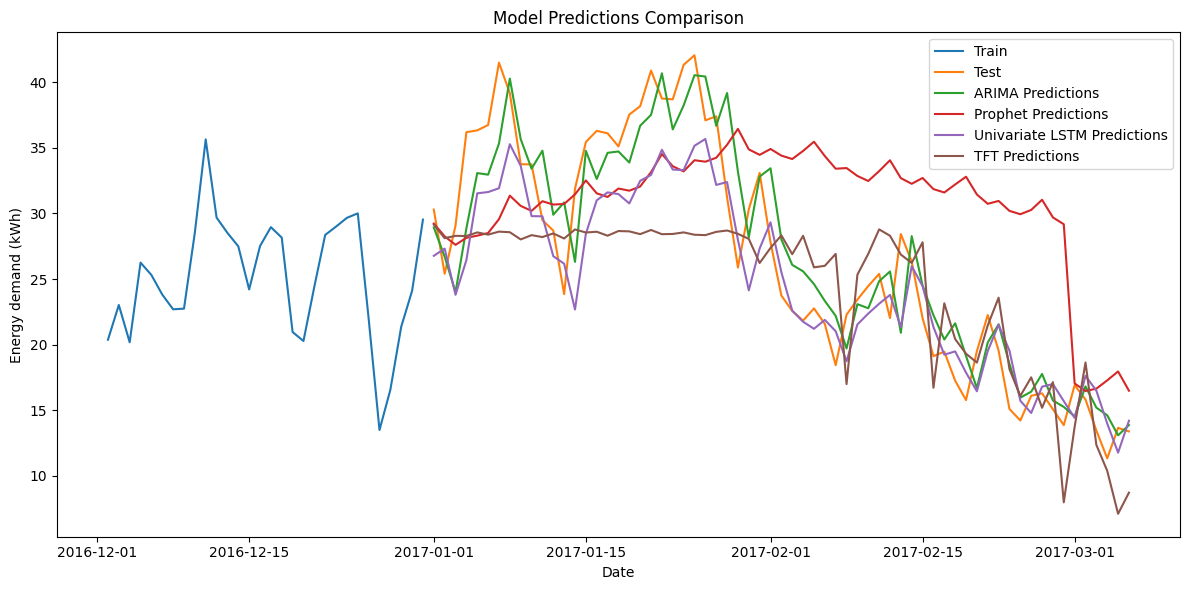

In [608]:
# plot
plt.figure(figsize=(12, 6))
plt.plot(timestamps[timestamps.dt.year != 2017][-30:], train.iloc[-30:, 0], label="Train")
plt.plot(timestamps[timestamps.dt.year == 2017], test["energy_demand"], label="Test")
plt.plot(timestamps[timestamps.dt.year == 2017], results["ARIMA"]["preds"], label="ARIMA Predictions")
plt.plot(timestamps[timestamps.dt.year == 2017], results["Prophet"]["preds"], label="Prophet Predictions")
plt.plot(timestamps[timestamps.dt.year == 2017], results["Univariate LSTM"]["preds"], label="Univariate LSTM Predictions")
plt.plot(timestamps[timestamps.dt.year == 2017], results["TFT"]["preds"], label="TFT Predictions")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Energy demand (kWh)")
plt.title("Model Predictions Comparison")
plt.tight_layout()
plt.show()

In [609]:
# reporting results
for model_name, model_results in results.items():
    print(f"{model_name}:")
    print(f"  Time taken: {model_results['time']:.2f} seconds")
    print(f"  Memory usage: {model_results['memory'] / 1024 / 1024:.2f} MB")
    print(f"  Peak memory usage: {model_results['peak_memory'] / 1024 / 1024:.2f} MB")
    print()

Univariate LSTM:
  Time taken: 14.08 seconds
  Memory usage: 4.14 MB
  Peak memory usage: 4.20 MB

ARIMA:
  Time taken: 3.25 seconds
  Memory usage: 1.71 MB
  Peak memory usage: 3.30 MB

Prophet:
  Time taken: 12.69 seconds
  Memory usage: 0.89 MB
  Peak memory usage: 17.17 MB

TFT:
  Time taken: 194.04 seconds
  Memory usage: 1.27 MB
  Peak memory usage: 1.59 MB



Memory allocation and training + forecasting times are as expected for the given hardware. TFT is the most computationally expensive model which can be observed in the training time, yet we could not retrieve resource usage on GPU. LSTM is the second most expensive model but beacuse we didn't use too complex of an architecture, it is not much more expensive than ARIMA and Prophet. ARIMA and Prophet are the least computationally expensive models, with ARIMA being slightly more expensive than Prophet in terms of memory used. On the other hand Prophet takes longer, almost as much as LSTM to train beacuse of the one step ahead prediction loop which requires bulding a new model from scratch for each time step in the forecast horizon.

In [610]:
# table with RMSE, MAE and MAPE 
from sklearn.metrics import mean_squared_error, mean_absolute_error
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
metrics_df = []
for model_name, model_results in results.items():
    rmse = np.sqrt(mean_squared_error(test["energy_demand"], model_results["preds"]))
    mae = mean_absolute_error(test["energy_demand"], model_results["preds"])
    mape = mean_absolute_percentage_error(test["energy_demand"], model_results["preds"])
    metrics_df.append({"Model": model_name, "RMSE": rmse, "MAE": mae, "MAPE": mape})
metrics_df = pd.DataFrame(metrics_df).set_index("Model")
print(metrics_df)

                     RMSE       MAE       MAPE
Model                                         
Univariate LSTM  4.143191  3.334588  12.140172
ARIMA            3.379614  2.746433  11.040273
Prophet          9.015603  7.732307  35.865110
TFT              6.068117  4.961115  18.226471


Beacuse of reduced complexity of the dataset as well as its small size, ARIMA and Prophet perform very well, with ARIMA being the best model in terms of all three metrics. LSTM performs decently but is not able to outperform the classical models, which is expected given the simplicity of the dataset. TFT performs a little worse than LSTM, which is surprising given that it is a more complex model, but it is likely that the model was not able to converge in the given amount of time and epochs. Overall, for this particular dataset, ARIMA would be the recommended model, as it is the most accurate and computationally efficient. For more complex datasets with more features and longer sequences, LSTM or TFT might be better choices.